In [2]:
# =============================================================================
# Image Feature EDA for Amazon Product Sales Prediction
# =============================================================================
# This notebook explores the relationship between image features (extracted
# from the image_feature_extraction.ipynb pipeline) and two target variables:
#
# TARGET 1: Main BSR Rank - Overall bestseller rank in the main category
#           Columns: 'main_bsr_group', 'main_bsr_rank'
#
# TARGET 2: Lowest BSR Rank - Bestseller rank in the product's best subcategory
#           Columns: 'lowest_bsr_group', 'lowest_bsr_rank'
#
# Feature Groups from image_feature_extraction.ipynb:
# - Quality Features: brightness, contrast, saturation, colorfulness, sharpness, blur, entropy
# - Composition Features: edge_density, bg_uniformity, white_bg_pct, saliency, object_occupancy
# - OCR Features: text detection, word counts, claims detection
# - Object Detection Features: detected objects, bounding boxes, person/face detection
# - Embeddings: CNN (EfficientNet) and CLIP embeddings, compressed via PCA to 128 dimensions
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Plotting settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Color palettes for distinguishing between two targets
MAIN_BSR_COLOR = '#2E86AB'      # Blue for Main BSR
LOWEST_BSR_COLOR = '#A23B72'    # Magenta for Lowest BSR
PALETTE_MAIN = sns.color_palette("Blues", n_colors=5)
PALETTE_LOWEST = sns.color_palette("RdPu", n_colors=5)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
# =============================================================================
# 1. DATA LOADING AND OVERVIEW
# =============================================================================

# Load the dataset with image features
DATA_PATH = "../../data/products_with_image_feats.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Total products: {len(df):,}")
print(f"Total columns: {len(df.columns):,}")

Dataset shape: (36879, 7652)
Total products: 36,879
Total columns: 7,652


In [4]:
# Define feature groups based on image_feature_extraction.ipynb
# Each group has mean, max, std aggregations + hero_ version for hero image

# Target columns
TARGET_COLS = {
    'main_bsr': ['main_bsr_group', 'main_bsr_rank'],
    'lowest_bsr': ['lowest_bsr_group', 'lowest_bsr_rank']
}

# Quality Features (technical image quality)
QUALITY_BASE_FEATURES = [
    'width', 'height', 'aspect_ratio', 'filesize_kb',
    'brightness_mean', 'brightness_std', 'contrast',
    'saturation_mean', 'saturation_std', 'colorfulness',
    'sharpness_laplacian_var', 'blur_score', 'entropy',
    'exposure_clipped_high_pct', 'exposure_clipped_low_pct'
]

# Composition Features (visual composition and layout)
COMPOSITION_BASE_FEATURES = [
    'edge_density', 'bg_uniformity', 'white_bg_pct',
    'dominant_color_count', 'saliency_peak_ratio',
    'saliency_center_dist', 'object_occupancy_proxy', 'border_clutter_score'
]

# OCR Features (text detection)
OCR_BASE_FEATURES = [
    'ocr_char_count', 'ocr_word_count', 'ocr_num_count',
    'ocr_allcaps_ratio', 'ocr_has_units', 'ocr_has_claims',
    'text_overlay_area_proxy'
]

# Object Detection Features
DETECTION_BASE_FEATURES = [
    'det_num_objects', 'det_main_box_area_ratio', 'det_main_box_center_dist',
    'det_has_person', 'det_has_face', 'det_has_hand',
    'det_secondary_objects_count', 'det_conf_mean', 'det_conf_max'
]

# Helper function to get all aggregation columns for a base feature
def get_feature_cols(base_features, suffix='_mean'):
    """Get column names with given suffix for base features"""
    cols = []
    for feat in base_features:
        col = f"{feat}{suffix}"
        if col in df.columns:
            cols.append(col)
    return cols

# Get hero image columns
def get_hero_cols(base_features):
    """Get hero image columns for base features"""
    cols = []
    for feat in base_features:
        col = f"hero_{feat}"
        if col in df.columns:
            cols.append(col)
    return cols

print("Feature groups defined:")
print(f"  - Quality features: {len(QUALITY_BASE_FEATURES)} base features")
print(f"  - Composition features: {len(COMPOSITION_BASE_FEATURES)} base features")
print(f"  - OCR features: {len(OCR_BASE_FEATURES)} base features")
print(f"  - Detection features: {len(DETECTION_BASE_FEATURES)} base features")

Feature groups defined:
  - Quality features: 15 base features
  - Composition features: 8 base features
  - OCR features: 7 base features
  - Detection features: 9 base features


In [5]:
# Check for products with image features
df_with_images = df[df['num_images'].notna()].copy()
print(f"Products with image features: {len(df_with_images):,} ({len(df_with_images)/len(df)*100:.1f}%)")

# Check target variable availability
print("\n" + "="*60)
print("TARGET VARIABLE AVAILABILITY")
print("="*60)

main_bsr_available = df_with_images['main_bsr_rank'].notna().sum()
lowest_bsr_available = df_with_images['lowest_bsr_rank'].notna().sum()

print(f"\nMain BSR Rank:")
print(f"  - Available: {main_bsr_available:,} products ({main_bsr_available/len(df_with_images)*100:.1f}%)")
print(f"  - Missing: {len(df_with_images) - main_bsr_available:,} products")

print(f"\nLowest BSR Rank:")
print(f"  - Available: {lowest_bsr_available:,} products ({lowest_bsr_available/len(df_with_images)*100:.1f}%)")
print(f"  - Missing: {len(df_with_images) - lowest_bsr_available:,} products")

# Filter to products with both image features and at least one target
df_analysis = df_with_images[
    (df_with_images['main_bsr_rank'].notna()) | 
    (df_with_images['lowest_bsr_rank'].notna())
].copy()
print(f"\nProducts with image features AND at least one target: {len(df_analysis):,}")

Products with image features: 36,879 (100.0%)

TARGET VARIABLE AVAILABILITY

Main BSR Rank:
  - Available: 25,766 products (69.9%)
  - Missing: 11,113 products

Lowest BSR Rank:
  - Available: 25,766 products (69.9%)
  - Missing: 11,113 products

Products with image features AND at least one target: 25,766


---
## 2. TARGET VARIABLE ANALYSIS
We have two prediction targets:
1. **Main BSR Rank** (`main_bsr_rank`): Overall bestseller rank within the product's main category
2. **Lowest BSR Rank** (`lowest_bsr_rank`): Bestseller rank in the subcategory where the product performs best

Lower rank = better performance (rank 1 is the best seller)

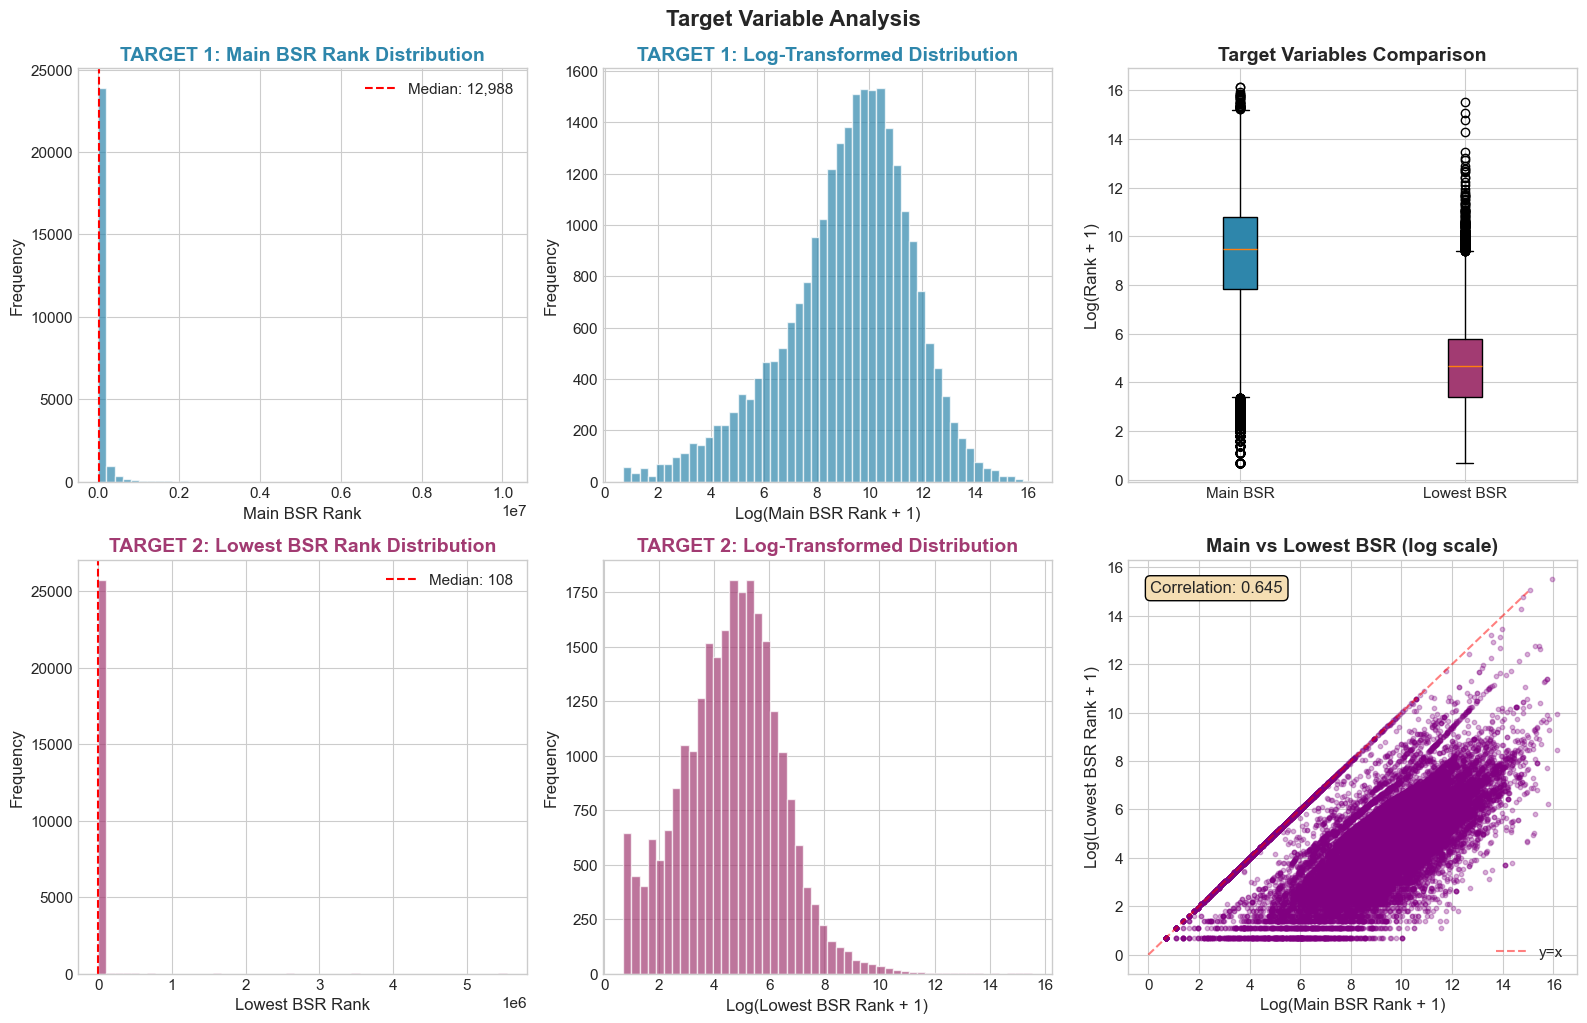


TARGET VARIABLE STATISTICS

Main BSR Rank (TARGET 1):
count    2.576600e+04
mean     7.755654e+04
std      3.104504e+05
min      1.000000e+00
25%      2.511000e+03
50%      1.298800e+04
75%      4.823050e+04
max      1.010140e+07
Name: main_bsr_rank, dtype: float64

Lowest BSR Rank (TARGET 2):
count    2.576600e+04
mean     1.275509e+03
std      4.596694e+04
min      1.000000e+00
25%      2.900000e+01
50%      1.080000e+02
75%      3.280000e+02
max      5.537959e+06
Name: lowest_bsr_rank, dtype: float64


In [6]:
# Target Variable Distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Main BSR Rank Distribution
ax1 = axes[0, 0]
main_bsr_data = df_analysis['main_bsr_rank'].dropna()
ax1.hist(main_bsr_data, bins=50, color=MAIN_BSR_COLOR, alpha=0.7, edgecolor='white')
ax1.set_xlabel('Main BSR Rank')
ax1.set_ylabel('Frequency')
ax1.set_title('TARGET 1: Main BSR Rank Distribution', fontweight='bold', color=MAIN_BSR_COLOR)
ax1.axvline(main_bsr_data.median(), color='red', linestyle='--', label=f'Median: {main_bsr_data.median():,.0f}')
ax1.legend()

# Main BSR Rank Log Distribution
ax2 = axes[0, 1]
main_bsr_log = np.log1p(main_bsr_data)
ax2.hist(main_bsr_log, bins=50, color=MAIN_BSR_COLOR, alpha=0.7, edgecolor='white')
ax2.set_xlabel('Log(Main BSR Rank + 1)')
ax2.set_ylabel('Frequency')
ax2.set_title('TARGET 1: Log-Transformed Distribution', fontweight='bold', color=MAIN_BSR_COLOR)

# Lowest BSR Rank Distribution
ax3 = axes[1, 0]
lowest_bsr_data = df_analysis['lowest_bsr_rank'].dropna()
ax3.hist(lowest_bsr_data, bins=50, color=LOWEST_BSR_COLOR, alpha=0.7, edgecolor='white')
ax3.set_xlabel('Lowest BSR Rank')
ax3.set_ylabel('Frequency')
ax3.set_title('TARGET 2: Lowest BSR Rank Distribution', fontweight='bold', color=LOWEST_BSR_COLOR)
ax3.axvline(lowest_bsr_data.median(), color='red', linestyle='--', label=f'Median: {lowest_bsr_data.median():,.0f}')
ax3.legend()

# Lowest BSR Rank Log Distribution
ax4 = axes[1, 1]
lowest_bsr_log = np.log1p(lowest_bsr_data)
ax4.hist(lowest_bsr_log, bins=50, color=LOWEST_BSR_COLOR, alpha=0.7, edgecolor='white')
ax4.set_xlabel('Log(Lowest BSR Rank + 1)')
ax4.set_ylabel('Frequency')
ax4.set_title('TARGET 2: Log-Transformed Distribution', fontweight='bold', color=LOWEST_BSR_COLOR)

# Comparison Boxplot
ax5 = axes[0, 2]
box_data = pd.DataFrame({
    'Main BSR Rank (log)': np.log1p(df_analysis['main_bsr_rank']),
    'Lowest BSR Rank (log)': np.log1p(df_analysis['lowest_bsr_rank'])
})
bp = ax5.boxplot([box_data['Main BSR Rank (log)'].dropna(), 
                   box_data['Lowest BSR Rank (log)'].dropna()],
                  labels=['Main BSR', 'Lowest BSR'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor(MAIN_BSR_COLOR)
bp['boxes'][1].set_facecolor(LOWEST_BSR_COLOR)
ax5.set_ylabel('Log(Rank + 1)')
ax5.set_title('Target Variables Comparison', fontweight='bold')

# Scatter plot: Main vs Lowest BSR
ax6 = axes[1, 2]
both_targets = df_analysis[df_analysis['main_bsr_rank'].notna() & df_analysis['lowest_bsr_rank'].notna()]
ax6.scatter(np.log1p(both_targets['main_bsr_rank']), 
            np.log1p(both_targets['lowest_bsr_rank']),
            alpha=0.3, s=10, c='purple')
ax6.plot([0, 15], [0, 15], 'r--', alpha=0.5, label='y=x')
ax6.set_xlabel('Log(Main BSR Rank + 1)')
ax6.set_ylabel('Log(Lowest BSR Rank + 1)')
ax6.set_title('Main vs Lowest BSR (log scale)', fontweight='bold')
corr = np.corrcoef(np.log1p(both_targets['main_bsr_rank']), 
                   np.log1p(both_targets['lowest_bsr_rank']))[0, 1]
ax6.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax6.transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
ax6.legend()

plt.tight_layout()
plt.suptitle('Target Variable Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Statistics
print("\n" + "="*60)
print("TARGET VARIABLE STATISTICS")
print("="*60)
print("\nMain BSR Rank (TARGET 1):")
print(main_bsr_data.describe())
print("\nLowest BSR Rank (TARGET 2):")
print(lowest_bsr_data.describe())

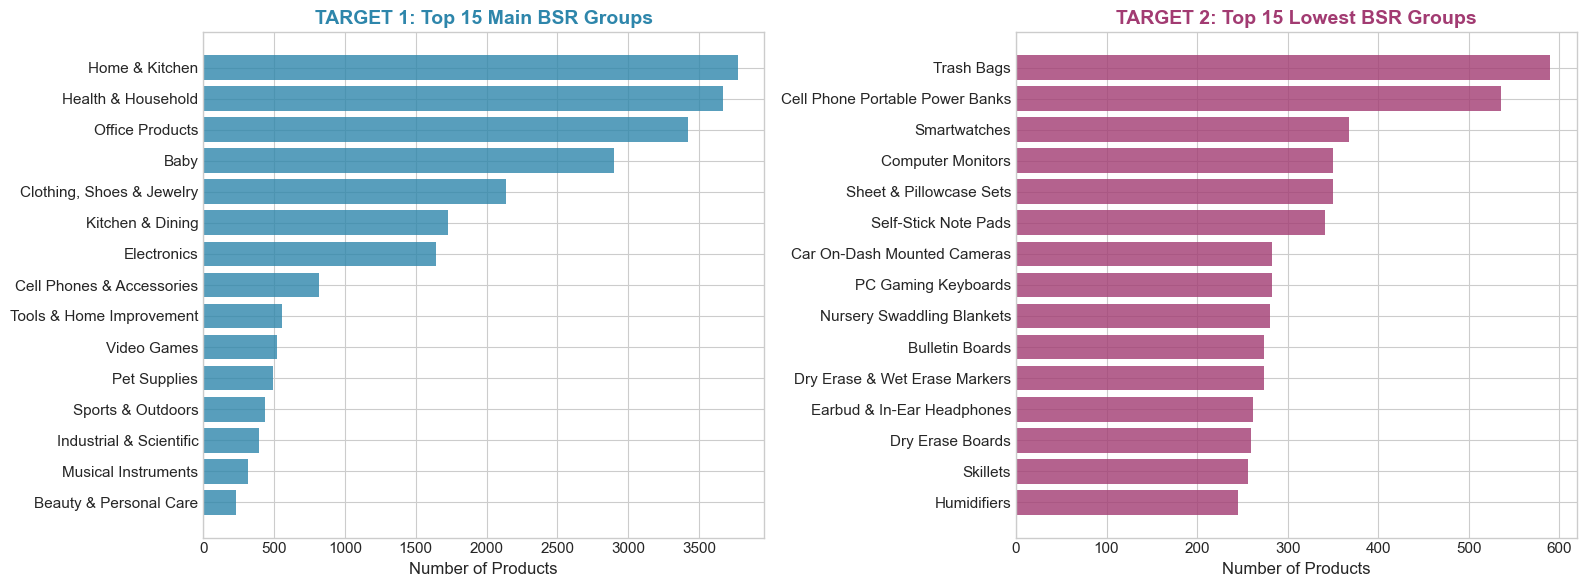


Unique Main BSR Groups: 142
Unique Lowest BSR Groups: 1611


In [8]:
# BSR Group Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Main BSR Groups
ax1 = axes[0]
main_groups = df_analysis['main_bsr_group'].value_counts().head(15)
bars1 = ax1.barh(range(len(main_groups)), main_groups.values, color=MAIN_BSR_COLOR, alpha=0.8)
ax1.set_yticks(range(len(main_groups)))
ax1.set_yticklabels([str(g)[:40] + '...' if len(str(g)) > 40 else str(g) for g in main_groups.index])
ax1.set_xlabel('Number of Products')
ax1.set_title('TARGET 1: Top 15 Main BSR Groups', fontweight='bold', color=MAIN_BSR_COLOR)
ax1.invert_yaxis()

# Lowest BSR Groups
ax2 = axes[1]
lowest_groups = df_analysis['lowest_bsr_group'].value_counts().head(15)
bars2 = ax2.barh(range(len(lowest_groups)), lowest_groups.values, color=LOWEST_BSR_COLOR, alpha=0.8)
ax2.set_yticks(range(len(lowest_groups)))
ax2.set_yticklabels([str(g)[:40] + '...' if len(str(g)) > 40 else str(g) for g in lowest_groups.index])
ax2.set_xlabel('Number of Products')
ax2.set_title('TARGET 2: Top 15 Lowest BSR Groups', fontweight='bold', color=LOWEST_BSR_COLOR)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nUnique Main BSR Groups: {df_analysis['main_bsr_group'].nunique()}")
print(f"Unique Lowest BSR Groups: {df_analysis['lowest_bsr_group'].nunique()}")

---
## 3. IMAGE QUALITY FEATURES
From `image_feature_extraction.ipynb`: Technical quality metrics computed using OpenCV and scikit-image
- **Dimensions**: width, height, aspect_ratio, filesize_kb
- **Brightness/Contrast**: brightness_mean, brightness_std, contrast
- **Color**: saturation_mean, saturation_std, colorfulness
- **Sharpness/Blur**: sharpness_laplacian_var (Laplacian variance), blur_score
- **Entropy**: Information content measure
- **Exposure**: exposure_clipped_high_pct, exposure_clipped_low_pct (over/under-exposed pixels)

Quality Feature Columns (mean aggregation):
['width_mean', 'height_mean', 'aspect_ratio_mean', 'filesize_kb_mean', 'brightness_mean_mean', 'brightness_std_mean', 'contrast_mean', 'saturation_mean_mean', 'saturation_std_mean', 'colorfulness_mean', 'sharpness_laplacian_var_mean', 'blur_score_mean', 'entropy_mean', 'exposure_clipped_high_pct_mean', 'exposure_clipped_low_pct_mean']


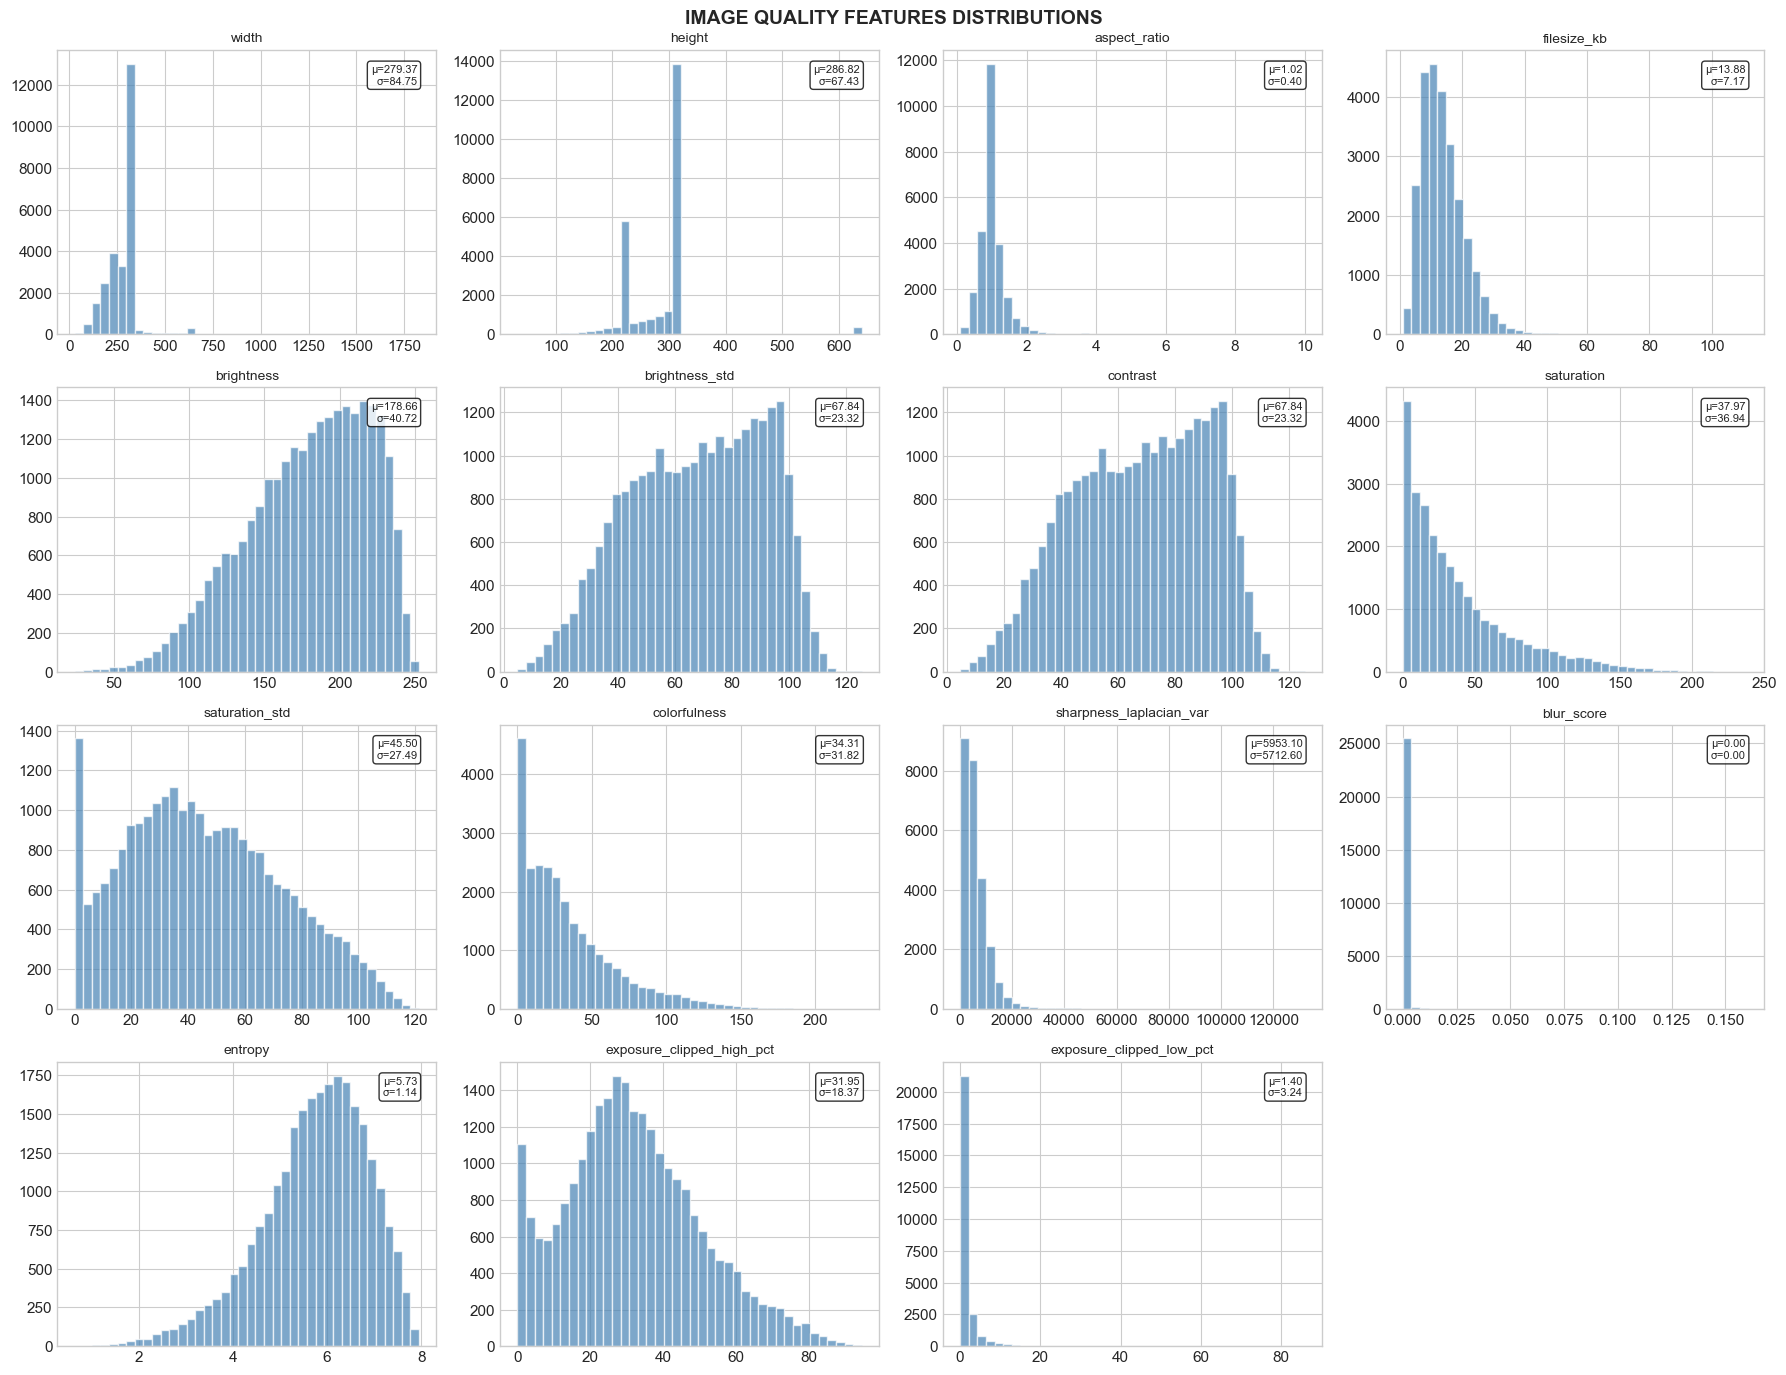

In [15]:
# Quality Features Distribution
quality_cols_mean = get_feature_cols(QUALITY_BASE_FEATURES, '_mean')
quality_cols_hero = get_hero_cols(QUALITY_BASE_FEATURES)

print("Quality Feature Columns (mean aggregation):")
print(quality_cols_mean)

# Create distribution plots for quality features
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for idx, col in enumerate(quality_cols_mean[:16]):
    ax = axes[idx]
    data = df_analysis[col].dropna()
    ax.hist(data, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_mean', ''), fontsize=10)
    ax.set_xlabel('')
    
    # Add statistics
    stats_text = f'μ={data.mean():.2f}\nσ={data.std():.2f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=8,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Hide unused subplots
for idx in range(len(quality_cols_mean), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('IMAGE QUALITY FEATURES DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Quality Features vs Both Targets - Scatter Plots
def plot_feature_vs_targets(feature_cols, feature_name, n_cols=4):
    """Plot features against both target variables"""
    n_features = len(feature_cols)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(20, n_rows * 4))
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    for idx, col in enumerate(feature_cols):
        row = idx // n_cols
        col_idx = idx % n_cols
        
        # Main BSR (left half)
        ax1 = axes[row, col_idx]
        mask_main = df_analysis[col].notna() & df_analysis['main_bsr_rank'].notna()
        if mask_main.sum() > 0:
            ax1.scatter(df_analysis.loc[mask_main, col], 
                       np.log1p(df_analysis.loc[mask_main, 'main_bsr_rank']),
                       alpha=0.2, s=5, c=MAIN_BSR_COLOR)
            # Add correlation
            corr = np.corrcoef(df_analysis.loc[mask_main, col], 
                              np.log1p(df_analysis.loc[mask_main, 'main_bsr_rank']))[0, 1]
            ax1.set_title(f'{col.replace("_mean", "")}\nr={corr:.3f}', fontsize=9, color=MAIN_BSR_COLOR)
        ax1.set_xlabel(col.replace('_mean', ''), fontsize=8)
        ax1.set_ylabel('Log(Main BSR)', fontsize=8)
        
        # Lowest BSR (right half)
        ax2 = axes[row, col_idx + n_cols]
        mask_lowest = df_analysis[col].notna() & df_analysis['lowest_bsr_rank'].notna()
        if mask_lowest.sum() > 0:
            ax2.scatter(df_analysis.loc[mask_lowest, col], 
                       np.log1p(df_analysis.loc[mask_lowest, 'lowest_bsr_rank']),
                       alpha=0.2, s=5, c=LOWEST_BSR_COLOR)
            # Add correlation
            corr = np.corrcoef(df_analysis.loc[mask_lowest, col], 
                              np.log1p(df_analysis.loc[mask_lowest, 'lowest_bsr_rank']))[0, 1]
            ax2.set_title(f'{col.replace("_mean", "")}\nr={corr:.3f}', fontsize=9, color=LOWEST_BSR_COLOR)
        ax2.set_xlabel(col.replace('_mean', ''), fontsize=8)
        ax2.set_ylabel('Log(Lowest BSR)', fontsize=8)
    
    # Hide unused subplots
    for idx in range(len(feature_cols), n_rows * n_cols):
        row = idx // n_cols
        col_idx = idx % n_cols
        axes[row, col_idx].set_visible(False)
        axes[row, col_idx + n_cols].set_visible(False)
    
    fig.suptitle(f'{feature_name} vs TARGETS\n[LEFT: Main BSR (blue)] [RIGHT: Lowest BSR (magenta)]', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot quality features vs targets
plot_feature_vs_targets(quality_cols_mean, 'QUALITY FEATURES')

---
## 4. COMPOSITION FEATURES
From `image_feature_extraction.ipynb`: Visual composition and layout analysis
- **edge_density**: Proportion of edge pixels (Canny edge detection)
- **bg_uniformity**: Standard deviation of border pixels (higher = less uniform background)
- **white_bg_pct**: Percentage of white background pixels
- **dominant_color_count**: Number of dominant colors (via K-means clustering)
- **saliency_peak_ratio**: Ratio of max to mean saliency (visual attention focus)
- **saliency_center_dist**: Distance of saliency center from image center
- **object_occupancy_proxy**: Estimated object coverage area
- **border_clutter_score**: Edge activity near image borders

Composition Feature Columns:
['edge_density_mean', 'bg_uniformity_mean', 'white_bg_pct_mean', 'dominant_color_count_mean', 'saliency_peak_ratio_mean', 'saliency_center_dist_mean', 'object_occupancy_proxy_mean', 'border_clutter_score_mean']


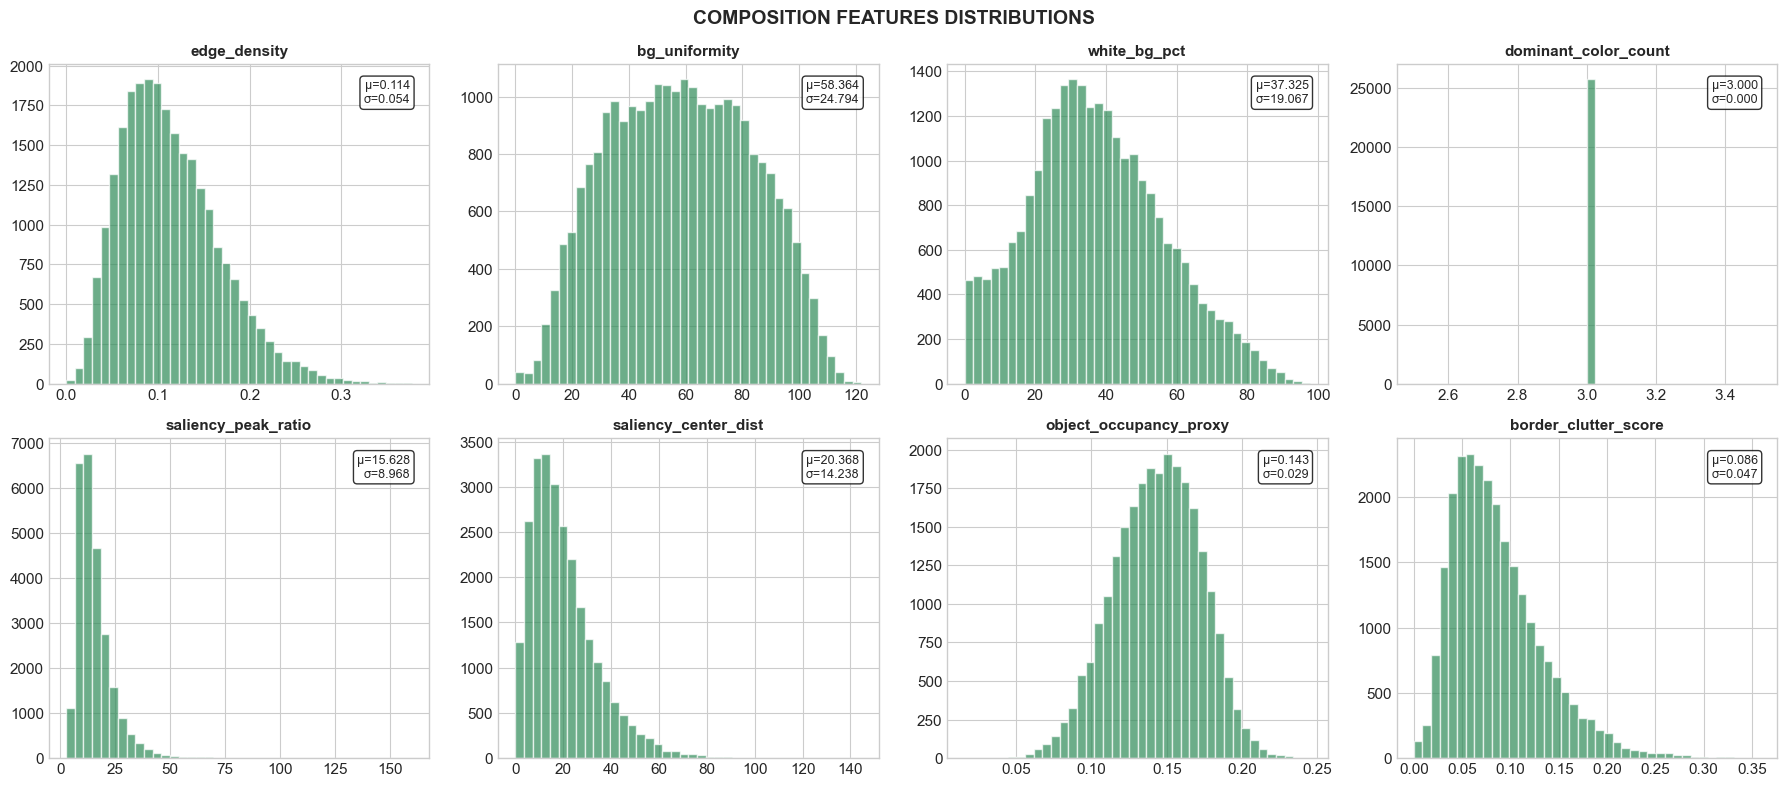

In [11]:
# Composition Features Distribution
composition_cols_mean = get_feature_cols(COMPOSITION_BASE_FEATURES, '_mean')

print("Composition Feature Columns:")
print(composition_cols_mean)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(composition_cols_mean[:8]):
    ax = axes[idx]
    data = df_analysis[col].dropna()
    ax.hist(data, bins=40, color='seagreen', alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_mean', ''), fontsize=11, fontweight='bold')
    
    # Add statistics
    stats_text = f'μ={data.mean():.3f}\nσ={data.std():.3f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

for idx in range(len(composition_cols_mean), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('COMPOSITION FEATURES DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

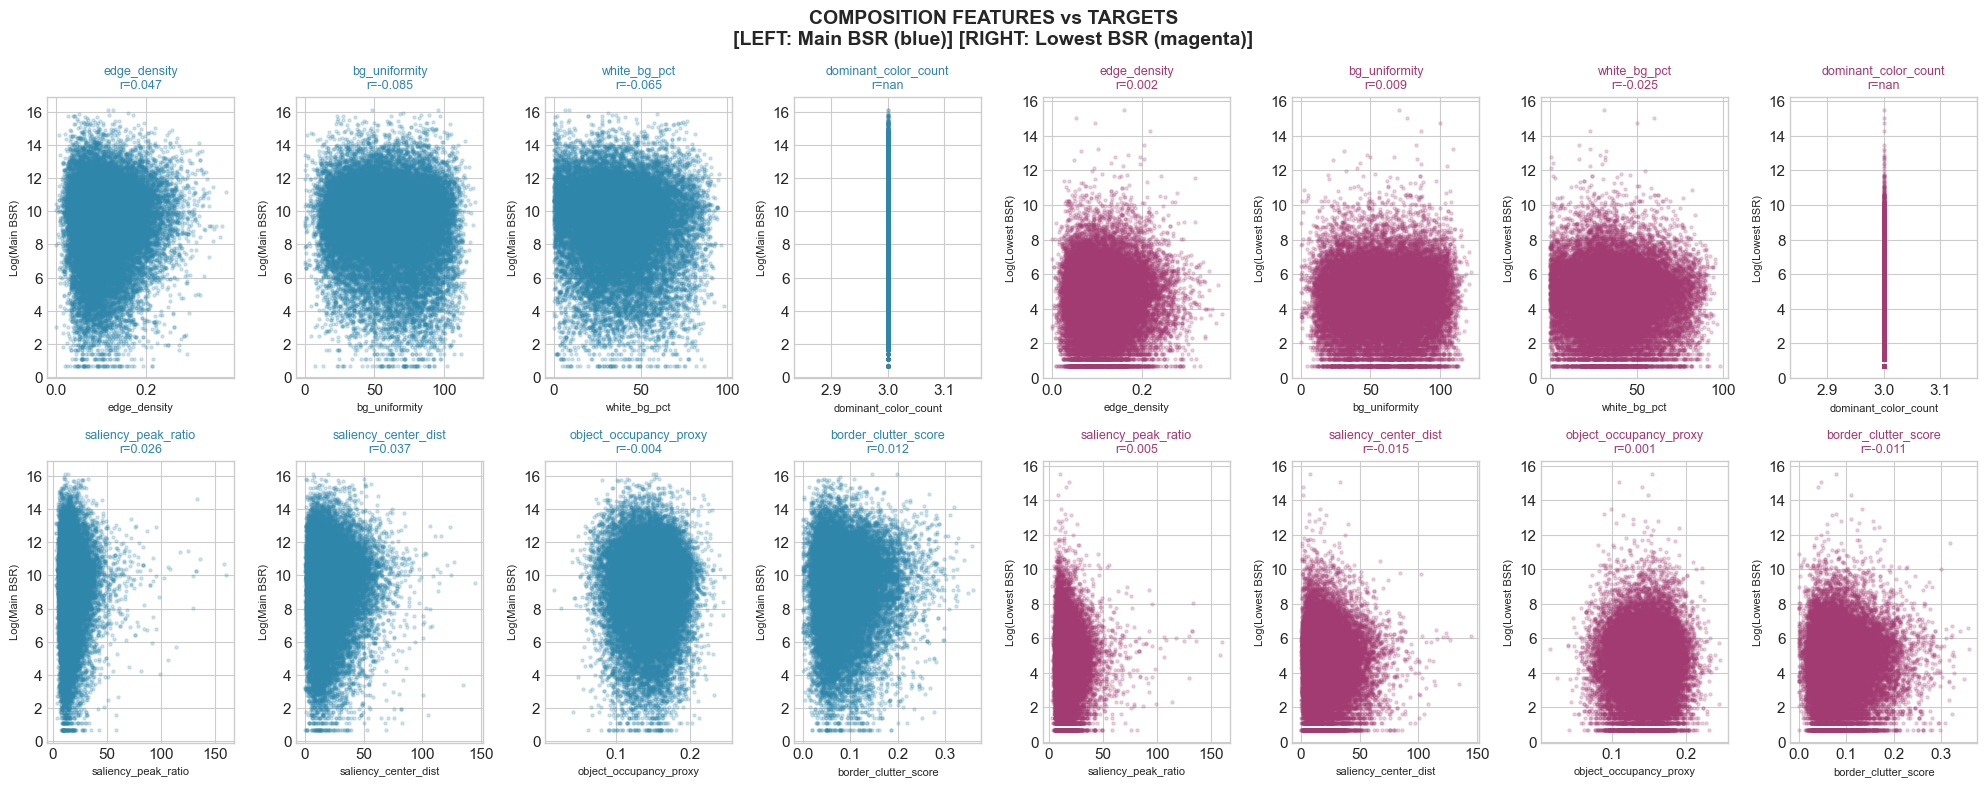

In [17]:
# Composition Features vs Both Targets
plot_feature_vs_targets(composition_cols_mean, 'COMPOSITION FEATURES', n_cols=4)

---
## 5. OCR (TEXT DETECTION) FEATURES
From `image_feature_extraction.ipynb`: Text detection using Tesseract OCR
- **ocr_char_count**: Total characters detected in image
- **ocr_word_count**: Total words detected
- **ocr_num_count**: Numeric tokens found (prices, quantities, etc.)
- **ocr_allcaps_ratio**: Ratio of ALL CAPS words
- **ocr_has_units**: Binary - presence of unit indicators (oz, lb, ml, pack, etc.)
- **ocr_has_claims**: Binary - presence of marketing claims (organic, premium, etc.)
- **text_overlay_area_proxy**: Estimated area covered by text overlays

OCR Feature Columns:
['ocr_char_count_mean', 'ocr_word_count_mean', 'ocr_num_count_mean', 'ocr_allcaps_ratio_mean', 'ocr_has_units_mean', 'ocr_has_claims_mean', 'text_overlay_area_proxy_mean']


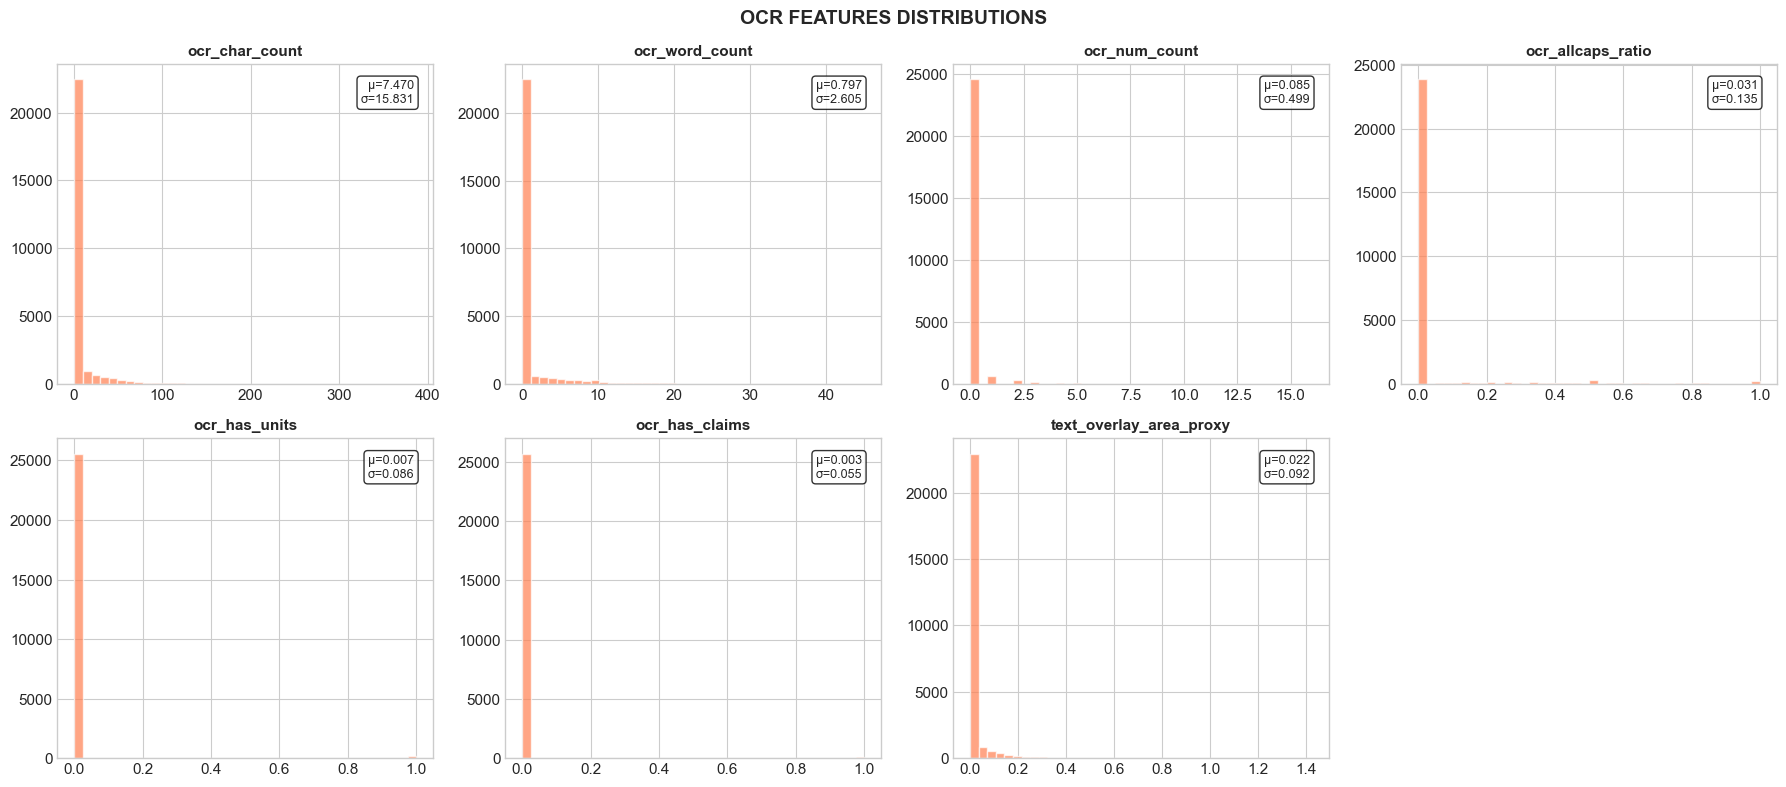

In [19]:
# OCR Features Distribution
ocr_cols_mean = get_feature_cols(OCR_BASE_FEATURES, '_mean')

print("OCR Feature Columns:")
print(ocr_cols_mean)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, col in enumerate(ocr_cols_mean[:8]):
    ax = axes[idx]
    data = df_analysis[col].dropna()
    ax.hist(data, bins=40, color='coral', alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_mean', ''), fontsize=11, fontweight='bold')
    
    # Add statistics
    stats_text = f'μ={data.mean():.3f}\nσ={data.std():.3f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

for idx in range(len(ocr_cols_mean), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('OCR FEATURES DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

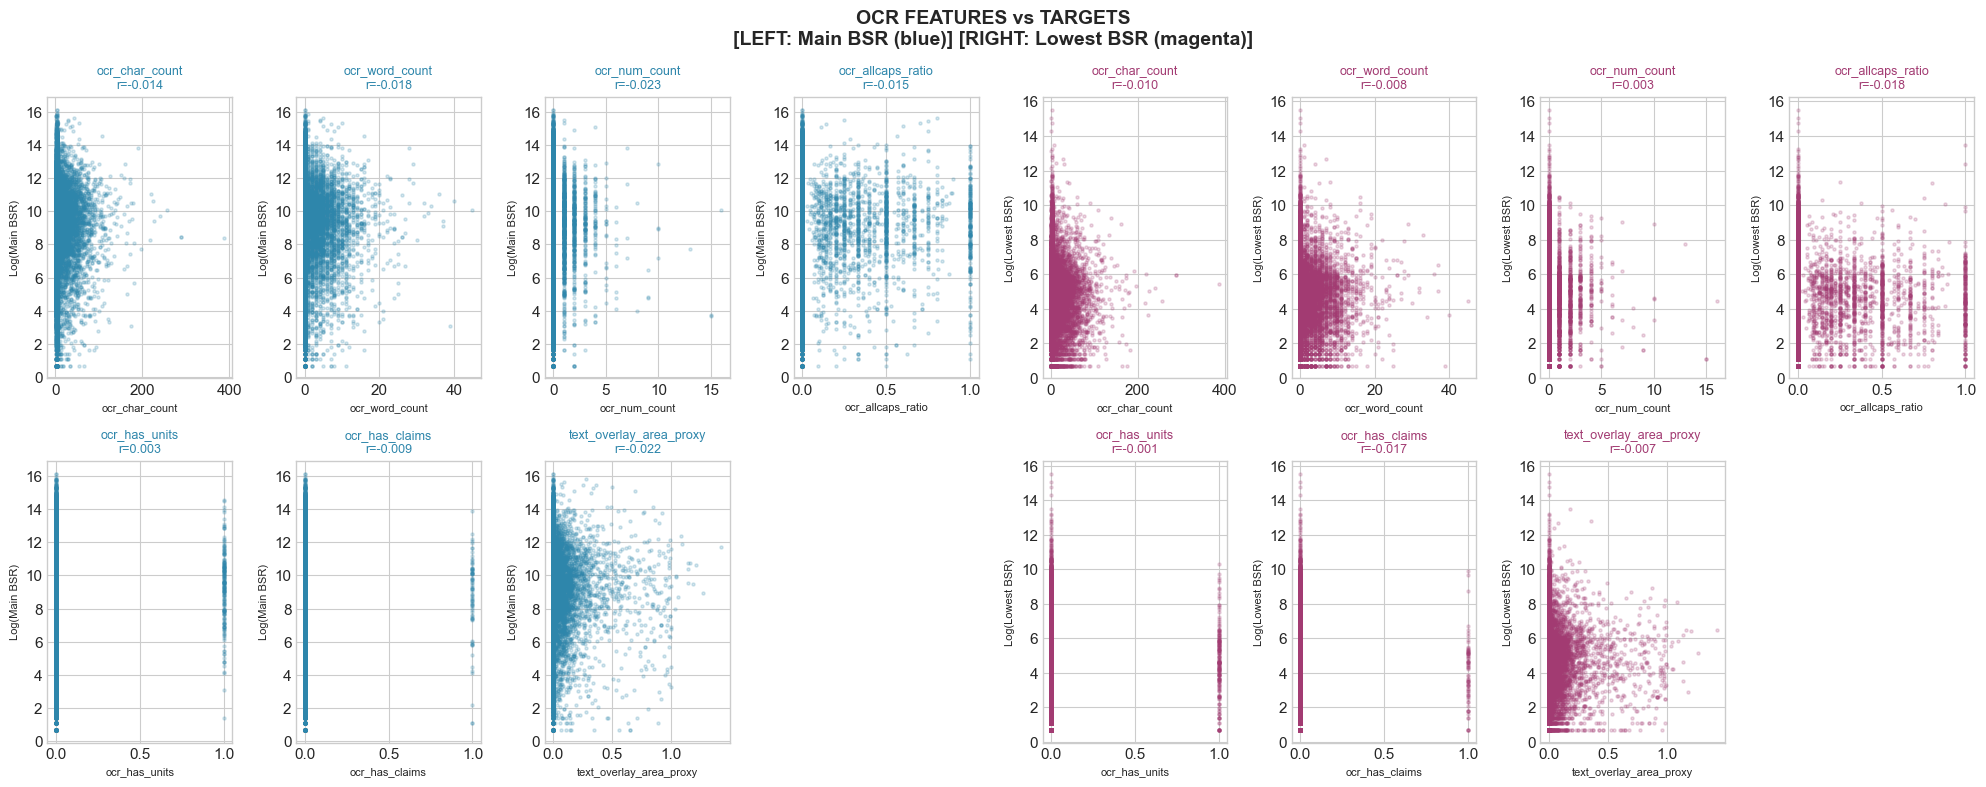

In [21]:
# OCR Features vs Both Targets
plot_feature_vs_targets(ocr_cols_mean, 'OCR FEATURES', n_cols=4)

---
## 6. OBJECT DETECTION FEATURES
From `image_feature_extraction.ipynb`: Object detection using YOLOv8
- **det_num_objects**: Number of detected objects in image
- **det_main_box_area_ratio**: Area ratio of main detected object to image
- **det_main_box_center_dist**: Distance of main object from image center
- **det_has_person**: Binary - person detected (lifestyle shot indicator)
- **det_has_face**: Binary - face detected
- **det_has_hand**: Binary - hand detected (usage demonstration)
- **det_secondary_objects_count**: Number of secondary objects
- **det_conf_mean/max**: Detection confidence scores

Detection Feature Columns:
['det_num_objects_mean', 'det_main_box_area_ratio_mean', 'det_main_box_center_dist_mean', 'det_has_person_mean', 'det_has_face_mean', 'det_has_hand_mean', 'det_secondary_objects_count_mean', 'det_conf_mean_mean', 'det_conf_max_mean']


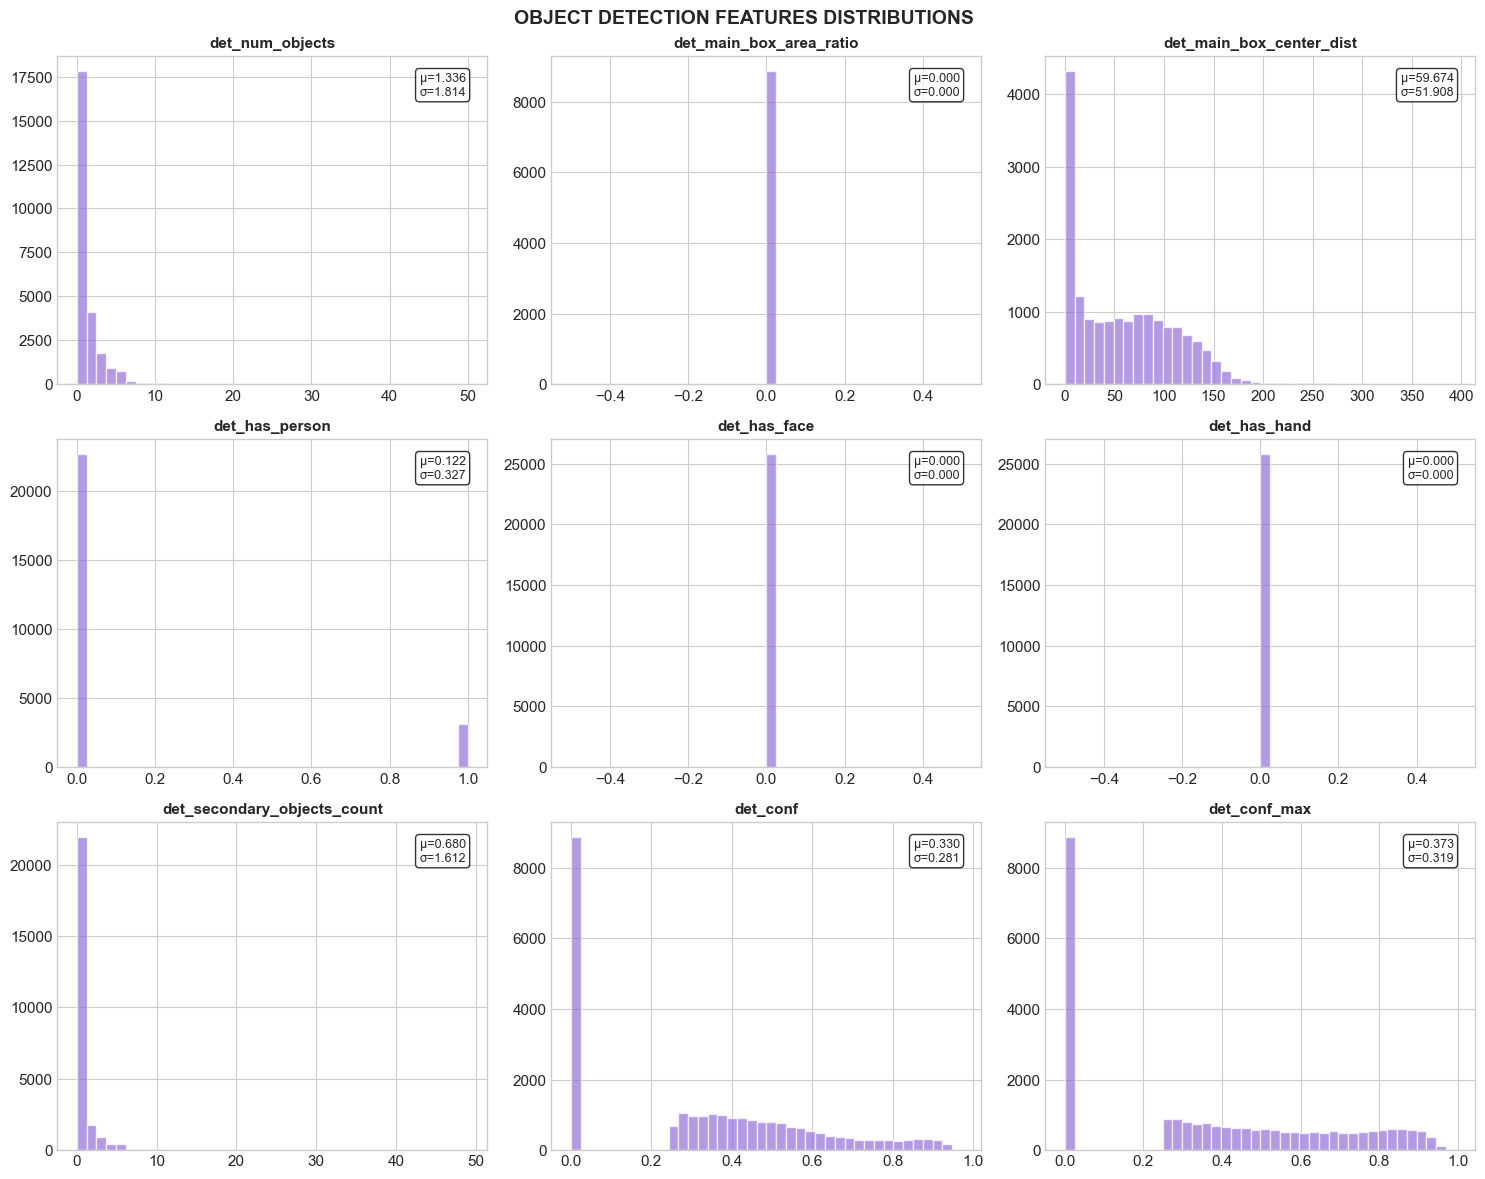

In [22]:
# Detection Features Distribution
detection_cols_mean = get_feature_cols(DETECTION_BASE_FEATURES, '_mean')

print("Detection Feature Columns:")
print(detection_cols_mean)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(detection_cols_mean[:9]):
    ax = axes[idx]
    data = df_analysis[col].dropna()
    ax.hist(data, bins=40, color='mediumpurple', alpha=0.7, edgecolor='white')
    ax.set_title(col.replace('_mean', ''), fontsize=11, fontweight='bold')
    
    # Add statistics
    stats_text = f'μ={data.mean():.3f}\nσ={data.std():.3f}'
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

for idx in range(len(detection_cols_mean), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('OBJECT DETECTION FEATURES DISTRIBUTIONS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

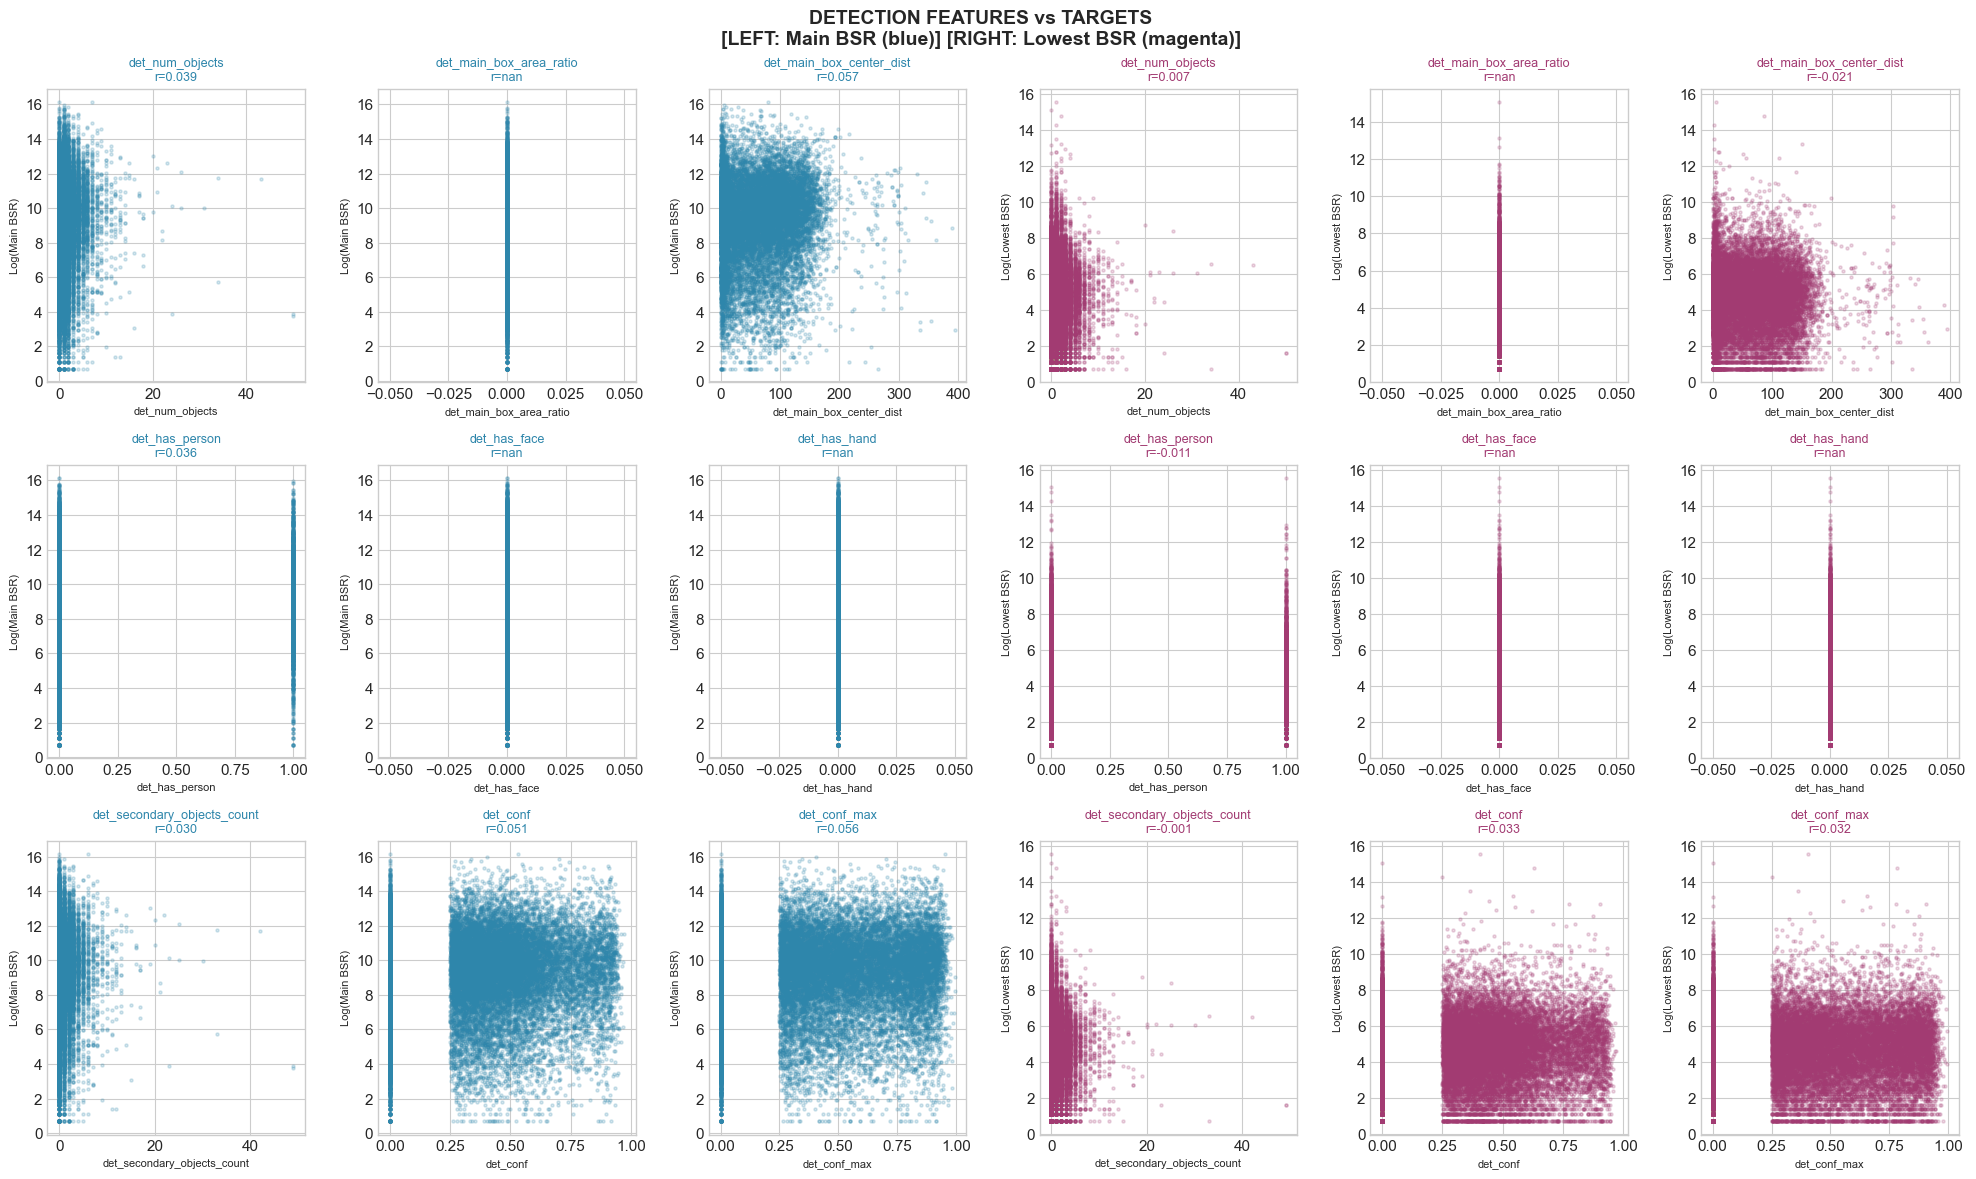

In [23]:
# Detection Features vs Both Targets
plot_feature_vs_targets(detection_cols_mean, 'DETECTION FEATURES', n_cols=3)

---
## 7. PCA EMBEDDING ANALYSIS
From `image_feature_extraction.ipynb`: Deep embeddings compressed via PCA
- **CNN PCA**: EfficientNet-B0 embeddings (1280 dims → 128 PCA components)
- **CLIP PCA**: OpenAI CLIP ViT-B/32 embeddings (512 dims → 128 PCA components)
- **clip_cnn_cos_sim**: Cosine similarity between CNN and CLIP embeddings (alignment metric)

In [24]:
# PCA Embedding Analysis
# Get PCA columns
cnn_pca_cols = [col for col in df_analysis.columns if col.startswith('cnn_pca_')]
clip_pca_cols = [col for col in df_analysis.columns if col.startswith('clip_pca_')]

print(f"CNN PCA components: {len(cnn_pca_cols)}")
print(f"CLIP PCA components: {len(clip_pca_cols)}")

# Check availability
cnn_available = df_analysis[cnn_pca_cols[0]].notna().sum() if cnn_pca_cols else 0
clip_available = df_analysis[clip_pca_cols[0]].notna().sum() if clip_pca_cols else 0
cos_sim_available = df_analysis['clip_cnn_cos_sim'].notna().sum() if 'clip_cnn_cos_sim' in df_analysis.columns else 0

print(f"\nProducts with CNN PCA: {cnn_available:,}")
print(f"Products with CLIP PCA: {clip_available:,}")
print(f"Products with CLIP-CNN cosine similarity: {cos_sim_available:,}")

CNN PCA components: 128
CLIP PCA components: 128

Products with CNN PCA: 25,766
Products with CLIP PCA: 25,766
Products with CLIP-CNN cosine similarity: 25,766


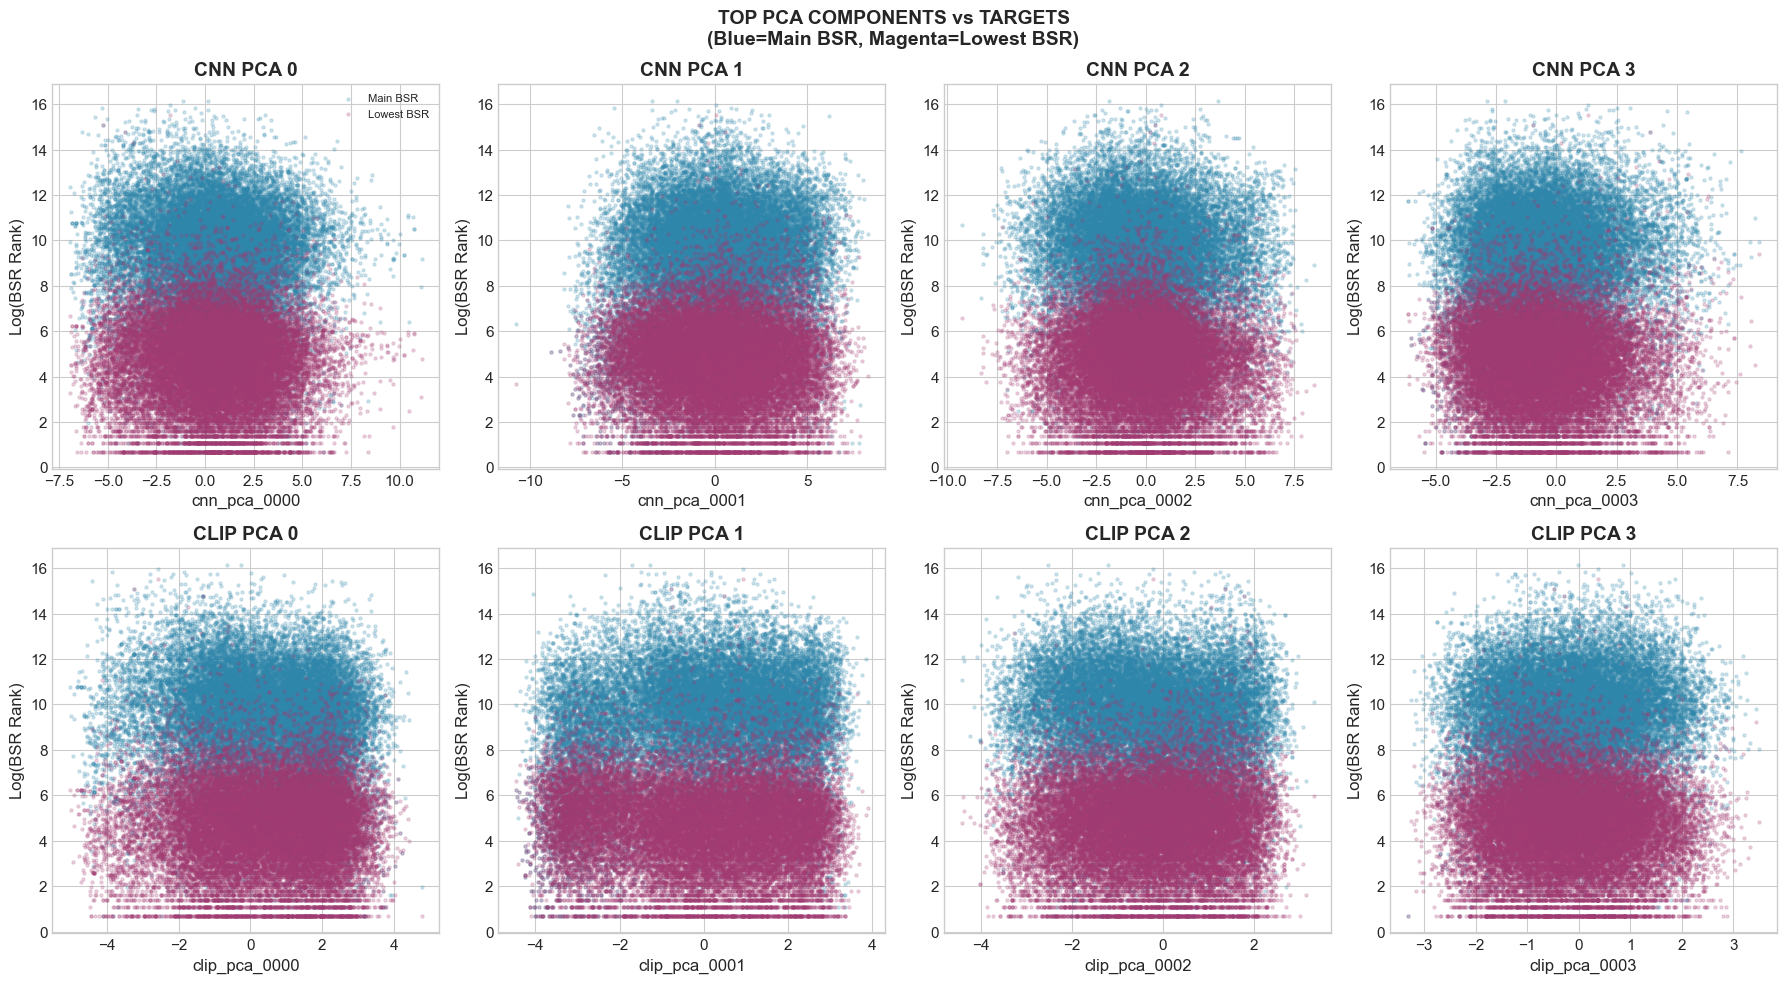

In [25]:
# Visualize first few PCA components and their relationship with targets
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# Top row: CNN PCA vs Targets
for i in range(4):
    ax = axes[0, i]
    col = cnn_pca_cols[i] if i < len(cnn_pca_cols) else None
    if col:
        mask = df_analysis[col].notna() & df_analysis['main_bsr_rank'].notna()
        if mask.sum() > 0:
            ax.scatter(df_analysis.loc[mask, col], 
                      np.log1p(df_analysis.loc[mask, 'main_bsr_rank']),
                      alpha=0.2, s=5, c=MAIN_BSR_COLOR, label='Main BSR')
            
            mask2 = df_analysis[col].notna() & df_analysis['lowest_bsr_rank'].notna()
            ax.scatter(df_analysis.loc[mask2, col], 
                      np.log1p(df_analysis.loc[mask2, 'lowest_bsr_rank']),
                      alpha=0.2, s=5, c=LOWEST_BSR_COLOR, label='Lowest BSR')
            
            ax.set_title(f'CNN PCA {i}', fontweight='bold')
            ax.set_xlabel(col)
            ax.set_ylabel('Log(BSR Rank)')
            if i == 0:
                ax.legend(fontsize=8)

# Bottom row: CLIP PCA vs Targets
for i in range(4):
    ax = axes[1, i]
    col = clip_pca_cols[i] if i < len(clip_pca_cols) else None
    if col:
        mask = df_analysis[col].notna() & df_analysis['main_bsr_rank'].notna()
        if mask.sum() > 0:
            ax.scatter(df_analysis.loc[mask, col], 
                      np.log1p(df_analysis.loc[mask, 'main_bsr_rank']),
                      alpha=0.2, s=5, c=MAIN_BSR_COLOR, label='Main BSR')
            
            mask2 = df_analysis[col].notna() & df_analysis['lowest_bsr_rank'].notna()
            ax.scatter(df_analysis.loc[mask2, col], 
                      np.log1p(df_analysis.loc[mask2, 'lowest_bsr_rank']),
                      alpha=0.2, s=5, c=LOWEST_BSR_COLOR, label='Lowest BSR')
            
            ax.set_title(f'CLIP PCA {i}', fontweight='bold')
            ax.set_xlabel(col)
            ax.set_ylabel('Log(BSR Rank)')

plt.suptitle('TOP PCA COMPONENTS vs TARGETS\n(Blue=Main BSR, Magenta=Lowest BSR)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

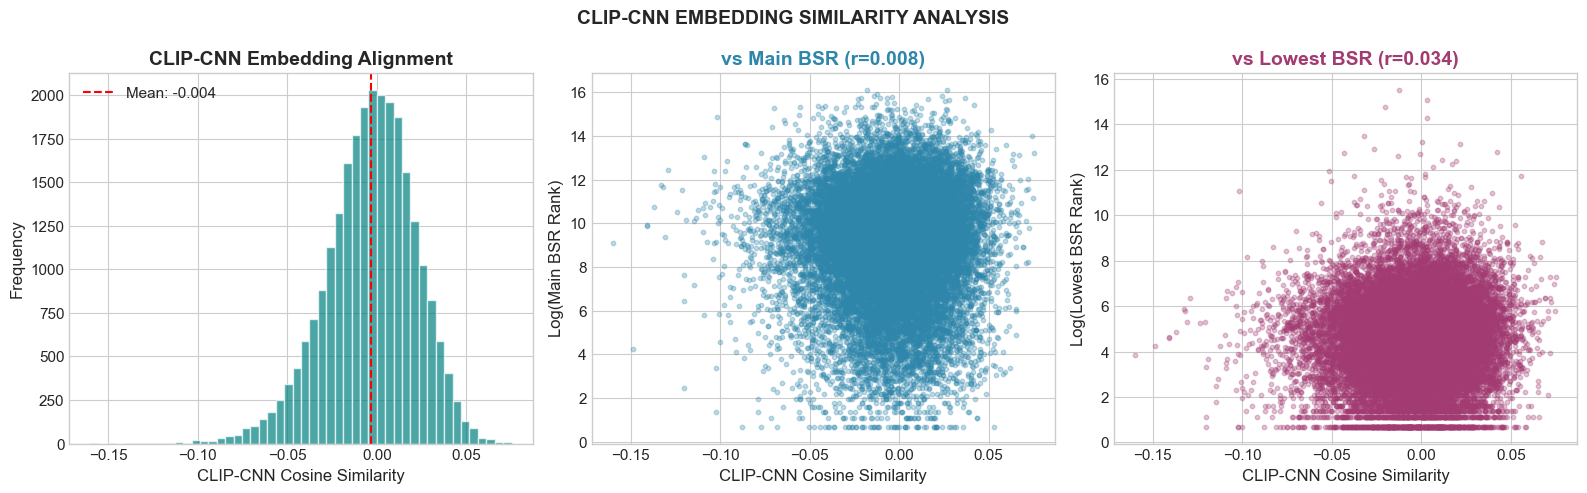

In [26]:
# CLIP-CNN Cosine Similarity Analysis
if 'clip_cnn_cos_sim' in df_analysis.columns:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Distribution
    ax1 = axes[0]
    cos_sim_data = df_analysis['clip_cnn_cos_sim'].dropna()
    ax1.hist(cos_sim_data, bins=50, color='teal', alpha=0.7, edgecolor='white')
    ax1.axvline(cos_sim_data.mean(), color='red', linestyle='--', 
                label=f'Mean: {cos_sim_data.mean():.3f}')
    ax1.set_xlabel('CLIP-CNN Cosine Similarity')
    ax1.set_ylabel('Frequency')
    ax1.set_title('CLIP-CNN Embedding Alignment', fontweight='bold')
    ax1.legend()
    
    # vs Main BSR
    ax2 = axes[1]
    mask_main = df_analysis['clip_cnn_cos_sim'].notna() & df_analysis['main_bsr_rank'].notna()
    if mask_main.sum() > 0:
        ax2.scatter(df_analysis.loc[mask_main, 'clip_cnn_cos_sim'],
                   np.log1p(df_analysis.loc[mask_main, 'main_bsr_rank']),
                   alpha=0.3, s=10, c=MAIN_BSR_COLOR)
        corr = np.corrcoef(df_analysis.loc[mask_main, 'clip_cnn_cos_sim'],
                          np.log1p(df_analysis.loc[mask_main, 'main_bsr_rank']))[0, 1]
        ax2.set_title(f'vs Main BSR (r={corr:.3f})', fontweight='bold', color=MAIN_BSR_COLOR)
    ax2.set_xlabel('CLIP-CNN Cosine Similarity')
    ax2.set_ylabel('Log(Main BSR Rank)')
    
    # vs Lowest BSR
    ax3 = axes[2]
    mask_lowest = df_analysis['clip_cnn_cos_sim'].notna() & df_analysis['lowest_bsr_rank'].notna()
    if mask_lowest.sum() > 0:
        ax3.scatter(df_analysis.loc[mask_lowest, 'clip_cnn_cos_sim'],
                   np.log1p(df_analysis.loc[mask_lowest, 'lowest_bsr_rank']),
                   alpha=0.3, s=10, c=LOWEST_BSR_COLOR)
        corr = np.corrcoef(df_analysis.loc[mask_lowest, 'clip_cnn_cos_sim'],
                          np.log1p(df_analysis.loc[mask_lowest, 'lowest_bsr_rank']))[0, 1]
        ax3.set_title(f'vs Lowest BSR (r={corr:.3f})', fontweight='bold', color=LOWEST_BSR_COLOR)
    ax3.set_xlabel('CLIP-CNN Cosine Similarity')
    ax3.set_ylabel('Log(Lowest BSR Rank)')
    
    plt.suptitle('CLIP-CNN EMBEDDING SIMILARITY ANALYSIS', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("clip_cnn_cos_sim column not found in dataset")

---
## 8. CORRELATION ANALYSIS
Comprehensive correlation analysis between image features and both BSR targets:
- Pearson correlation coefficients
- Spearman rank correlation (for non-linear relationships)
- Comparison between Main BSR and Lowest BSR correlations

In [27]:
# Comprehensive Correlation Analysis
def compute_correlations(df, feature_cols, target_col, method='pearson'):
    """Compute correlations between features and target"""
    correlations = {}
    for col in feature_cols:
        mask = df[col].notna() & df[target_col].notna()
        if mask.sum() > 10:
            if method == 'pearson':
                corr, pval = stats.pearsonr(df.loc[mask, col], np.log1p(df.loc[mask, target_col]))
            else:
                corr, pval = stats.spearmanr(df.loc[mask, col], df.loc[mask, target_col])
            correlations[col] = {'correlation': corr, 'p_value': pval, 'n': mask.sum()}
    return pd.DataFrame(correlations).T

# Collect all image feature columns (mean aggregation)
all_feature_cols = (
    get_feature_cols(QUALITY_BASE_FEATURES, '_mean') +
    get_feature_cols(COMPOSITION_BASE_FEATURES, '_mean') +
    get_feature_cols(OCR_BASE_FEATURES, '_mean') +
    get_feature_cols(DETECTION_BASE_FEATURES, '_mean') +
    ['num_images', 'clip_cnn_cos_sim']
)
all_feature_cols = [c for c in all_feature_cols if c in df_analysis.columns]

# Add first 10 PCA components
all_feature_cols += cnn_pca_cols[:10] + clip_pca_cols[:10]

# Compute correlations for both targets
print("Computing Pearson correlations...")
corr_main_pearson = compute_correlations(df_analysis, all_feature_cols, 'main_bsr_rank', 'pearson')
corr_lowest_pearson = compute_correlations(df_analysis, all_feature_cols, 'lowest_bsr_rank', 'pearson')

print("Computing Spearman correlations...")
corr_main_spearman = compute_correlations(df_analysis, all_feature_cols, 'main_bsr_rank', 'spearman')
corr_lowest_spearman = compute_correlations(df_analysis, all_feature_cols, 'lowest_bsr_rank', 'spearman')

print(f"Features analyzed: {len(all_feature_cols)}")

Computing Pearson correlations...
Computing Spearman correlations...
Features analyzed: 61


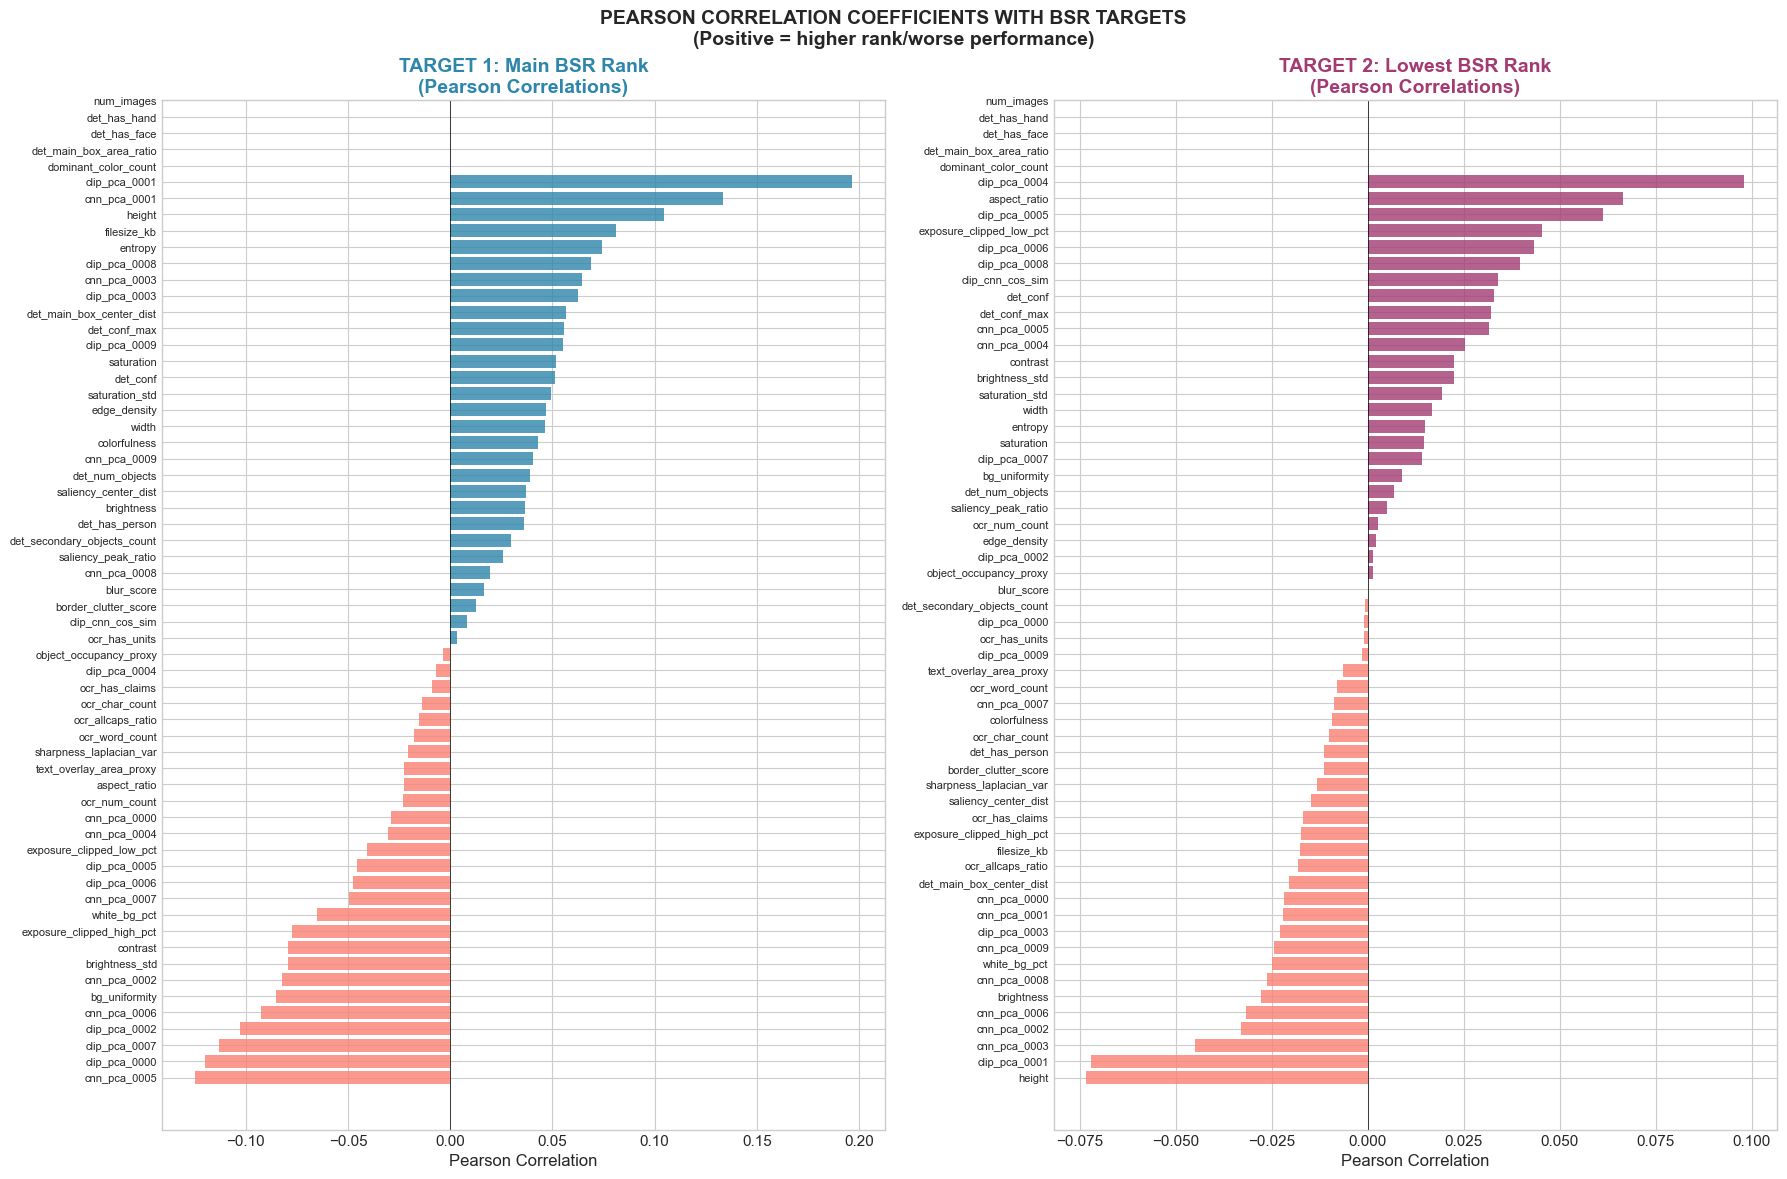

In [28]:
# Correlation Comparison Plot - Pearson
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# Main BSR Correlations (sorted)
ax1 = axes[0]
main_corr_sorted = corr_main_pearson['correlation'].sort_values()
colors_main = [MAIN_BSR_COLOR if c >= 0 else 'salmon' for c in main_corr_sorted.values]
y_pos = range(len(main_corr_sorted))
ax1.barh(y_pos, main_corr_sorted.values, color=colors_main, alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([s.replace('_mean', '') for s in main_corr_sorted.index], fontsize=8)
ax1.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Pearson Correlation')
ax1.set_title('TARGET 1: Main BSR Rank\n(Pearson Correlations)', fontweight='bold', color=MAIN_BSR_COLOR)

# Lowest BSR Correlations (sorted)
ax2 = axes[1]
lowest_corr_sorted = corr_lowest_pearson['correlation'].sort_values()
colors_lowest = [LOWEST_BSR_COLOR if c >= 0 else 'salmon' for c in lowest_corr_sorted.values]
y_pos = range(len(lowest_corr_sorted))
ax2.barh(y_pos, lowest_corr_sorted.values, color=colors_lowest, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([s.replace('_mean', '') for s in lowest_corr_sorted.index], fontsize=8)
ax2.axvline(0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Pearson Correlation')
ax2.set_title('TARGET 2: Lowest BSR Rank\n(Pearson Correlations)', fontweight='bold', color=LOWEST_BSR_COLOR)

plt.suptitle('PEARSON CORRELATION COEFFICIENTS WITH BSR TARGETS\n(Positive = higher rank/worse performance)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
# Side-by-side Correlation Comparison
# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Main BSR (Pearson)': corr_main_pearson['correlation'],
    'Lowest BSR (Pearson)': corr_lowest_pearson['correlation'],
    'Main BSR (Spearman)': corr_main_spearman['correlation'],
    'Lowest BSR (Spearman)': corr_lowest_spearman['correlation']
}).dropna()

# Sort by average absolute correlation
comparison_df['avg_abs_corr'] = (comparison_df['Main BSR (Pearson)'].abs() + 
                                  comparison_df['Lowest BSR (Pearson)'].abs()) / 2
comparison_df = comparison_df.sort_values('avg_abs_corr', ascending=False)

# Display top correlations
print("="*80)
print("TOP 20 FEATURES BY AVERAGE ABSOLUTE CORRELATION WITH TARGETS")
print("="*80)
print("\n(Positive correlation = higher rank = WORSE sales performance)")
print("(Negative correlation = lower rank = BETTER sales performance)\n")
display_df = comparison_df[['Main BSR (Pearson)', 'Lowest BSR (Pearson)', 
                            'Main BSR (Spearman)', 'Lowest BSR (Spearman)']].head(20)
print(display_df.round(4).to_string())

TOP 20 FEATURES BY AVERAGE ABSOLUTE CORRELATION WITH TARGETS

(Positive correlation = higher rank = WORSE sales performance)
(Negative correlation = lower rank = BETTER sales performance)

                                Main BSR (Pearson)  Lowest BSR (Pearson)  Main BSR (Spearman)  Lowest BSR (Spearman)
clip_pca_0001                               0.1967               -0.0722               0.1548                -0.0754
height_mean                                 0.1044               -0.0733               0.1449                -0.0753
cnn_pca_0005                               -0.1250                0.0315              -0.1193                 0.0287
cnn_pca_0001                                0.1335               -0.0221               0.1004                -0.0343
clip_pca_0007                              -0.1130                0.0140              -0.1182                 0.0191
cnn_pca_0006                               -0.0925               -0.0318              -0.1062                

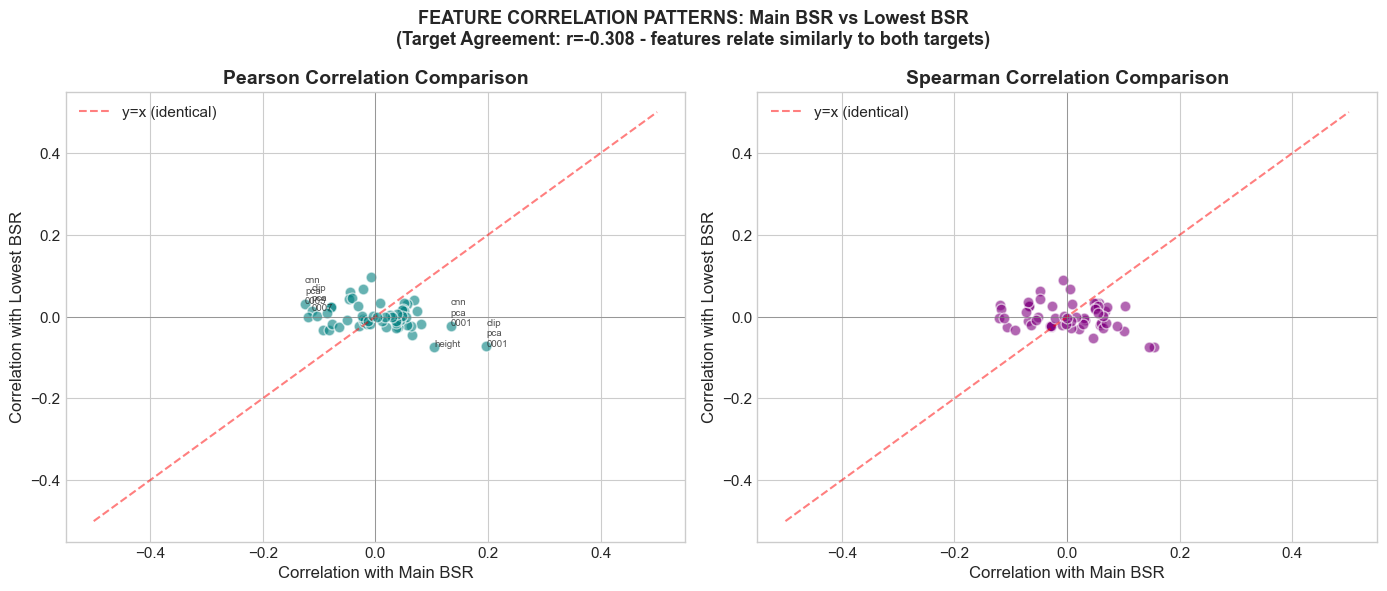

In [30]:
# Correlation scatter: Main vs Lowest BSR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pearson
ax1 = axes[0]
ax1.scatter(comparison_df['Main BSR (Pearson)'], 
            comparison_df['Lowest BSR (Pearson)'],
            alpha=0.6, s=60, c='teal', edgecolor='white')
ax1.plot([-0.5, 0.5], [-0.5, 0.5], 'r--', alpha=0.5, label='y=x (identical)')
ax1.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax1.axvline(0, color='gray', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Correlation with Main BSR', fontsize=12)
ax1.set_ylabel('Correlation with Lowest BSR', fontsize=12)
ax1.set_title('Pearson Correlation Comparison', fontweight='bold')
ax1.legend()

# Add annotations for outliers
for idx in comparison_df.head(5).index:
    ax1.annotate(idx.replace('_mean', '').replace('_', '\n'), 
                (comparison_df.loc[idx, 'Main BSR (Pearson)'],
                 comparison_df.loc[idx, 'Lowest BSR (Pearson)']),
                fontsize=7, alpha=0.8)

# Spearman
ax2 = axes[1]
ax2.scatter(comparison_df['Main BSR (Spearman)'], 
            comparison_df['Lowest BSR (Spearman)'],
            alpha=0.6, s=60, c='purple', edgecolor='white')
ax2.plot([-0.5, 0.5], [-0.5, 0.5], 'r--', alpha=0.5, label='y=x (identical)')
ax2.axhline(0, color='gray', linestyle='-', linewidth=0.5)
ax2.axvline(0, color='gray', linestyle='-', linewidth=0.5)
ax2.set_xlabel('Correlation with Main BSR', fontsize=12)
ax2.set_ylabel('Correlation with Lowest BSR', fontsize=12)
ax2.set_title('Spearman Correlation Comparison', fontweight='bold')
ax2.legend()

# Compute correlation between the two target correlations
corr_agreement = np.corrcoef(comparison_df['Main BSR (Pearson)'], 
                             comparison_df['Lowest BSR (Pearson)'])[0, 1]

plt.suptitle(f'FEATURE CORRELATION PATTERNS: Main BSR vs Lowest BSR\n' +
             f'(Target Agreement: r={corr_agreement:.3f} - features relate similarly to both targets)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. MUTUAL INFORMATION ANALYSIS
Mutual Information captures non-linear dependencies that Pearson/Spearman correlations may miss.
MI quantifies how much information a feature provides about the target variable.

Higher MI = stronger predictive relationship (regardless of linearity)

In [31]:
# Mutual Information Calculation
def compute_mutual_information(df, feature_cols, target_col, n_neighbors=5):
    """Compute mutual information between features and target"""
    # Get subset with no missing values in target
    mask_target = df[target_col].notna()
    df_subset = df[mask_target].copy()
    
    # Log-transform target
    y = np.log1p(df_subset[target_col]).values
    
    # Build feature matrix (impute NaNs with median for MI calculation)
    X_list = []
    valid_cols = []
    for col in feature_cols:
        if col in df_subset.columns:
            x = df_subset[col].values.copy()
            # Impute NaNs with median
            nan_mask = np.isnan(x)
            if nan_mask.sum() < len(x) * 0.5:  # Only include if <50% missing
                x[nan_mask] = np.nanmedian(x)
                X_list.append(x)
                valid_cols.append(col)
    
    if not X_list:
        return pd.Series()
    
    X = np.column_stack(X_list)
    
    # Compute mutual information
    mi_scores = mutual_info_regression(X, y, n_neighbors=n_neighbors, random_state=42)
    
    return pd.Series(mi_scores, index=valid_cols)

# Compute MI for both targets
print("Computing Mutual Information for Main BSR...")
mi_main = compute_mutual_information(df_analysis, all_feature_cols, 'main_bsr_rank')

print("Computing Mutual Information for Lowest BSR...")
mi_lowest = compute_mutual_information(df_analysis, all_feature_cols, 'lowest_bsr_rank')

print(f"\nFeatures with MI scores: {len(mi_main)}")

Computing Mutual Information for Main BSR...
Computing Mutual Information for Lowest BSR...

Features with MI scores: 60


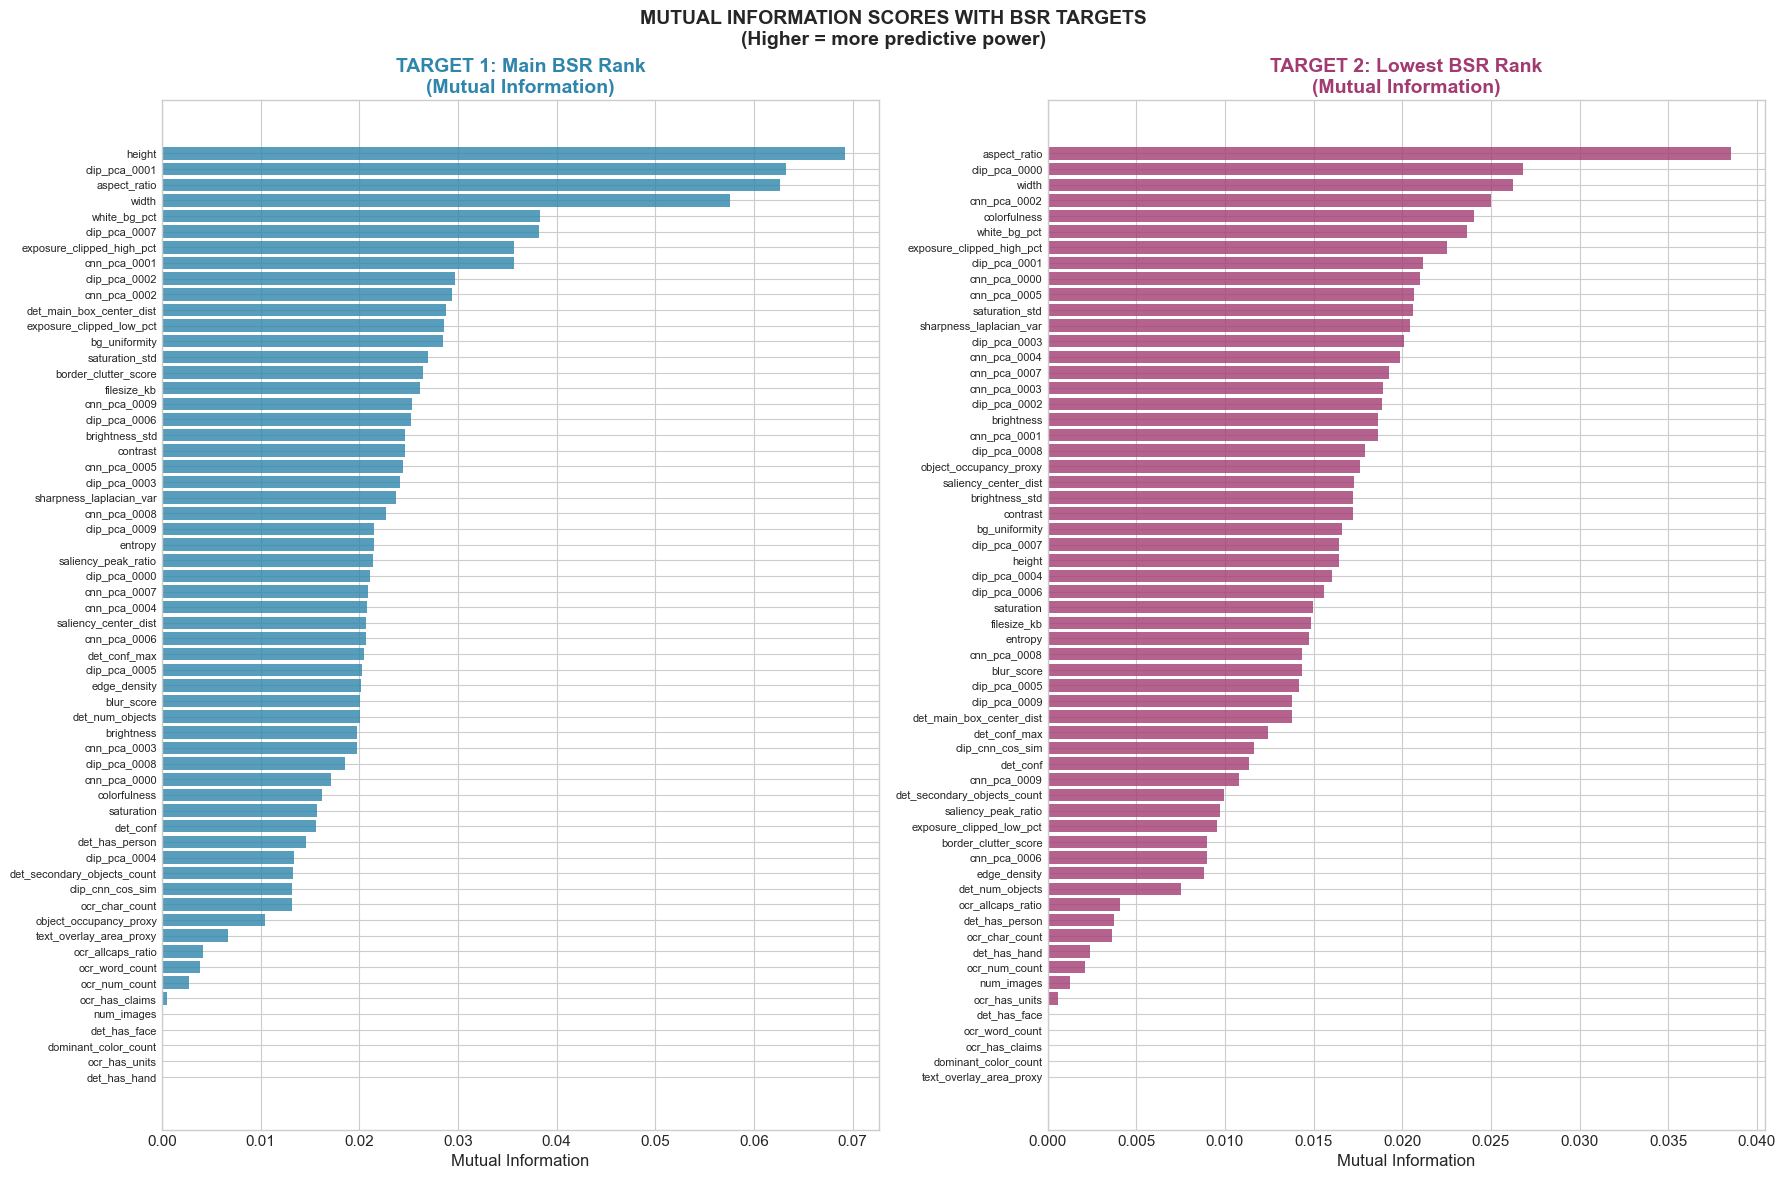

In [32]:
# Mutual Information Comparison Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

# Main BSR MI (sorted)
ax1 = axes[0]
mi_main_sorted = mi_main.sort_values(ascending=True)
y_pos = range(len(mi_main_sorted))
ax1.barh(y_pos, mi_main_sorted.values, color=MAIN_BSR_COLOR, alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([s.replace('_mean', '') for s in mi_main_sorted.index], fontsize=8)
ax1.set_xlabel('Mutual Information')
ax1.set_title('TARGET 1: Main BSR Rank\n(Mutual Information)', fontweight='bold', color=MAIN_BSR_COLOR)

# Lowest BSR MI (sorted)
ax2 = axes[1]
mi_lowest_sorted = mi_lowest.sort_values(ascending=True)
y_pos = range(len(mi_lowest_sorted))
ax2.barh(y_pos, mi_lowest_sorted.values, color=LOWEST_BSR_COLOR, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels([s.replace('_mean', '') for s in mi_lowest_sorted.index], fontsize=8)
ax2.set_xlabel('Mutual Information')
ax2.set_title('TARGET 2: Lowest BSR Rank\n(Mutual Information)', fontweight='bold', color=LOWEST_BSR_COLOR)

plt.suptitle('MUTUAL INFORMATION SCORES WITH BSR TARGETS\n(Higher = more predictive power)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

TOP 20 FEATURES BY MUTUAL INFORMATION

(Higher MI = more predictive information about target)

                                MI_Main_BSR  MI_Lowest_BSR  avg_MI
aspect_ratio_mean                    0.0627         0.0385  0.0506
height_mean                          0.0692         0.0164  0.0428
clip_pca_0001                        0.0632         0.0211  0.0422
width_mean                           0.0576         0.0262  0.0419
white_bg_pct_mean                    0.0384         0.0237  0.0310
exposure_clipped_high_pct_mean       0.0357         0.0225  0.0291
clip_pca_0007                        0.0382         0.0164  0.0273
cnn_pca_0002                         0.0295         0.0250  0.0272
cnn_pca_0001                         0.0357         0.0186  0.0272
clip_pca_0002                        0.0297         0.0189  0.0243
clip_pca_0000                        0.0211         0.0268  0.0240
saturation_std_mean                  0.0269         0.0206  0.0238
bg_uniformity_mean                

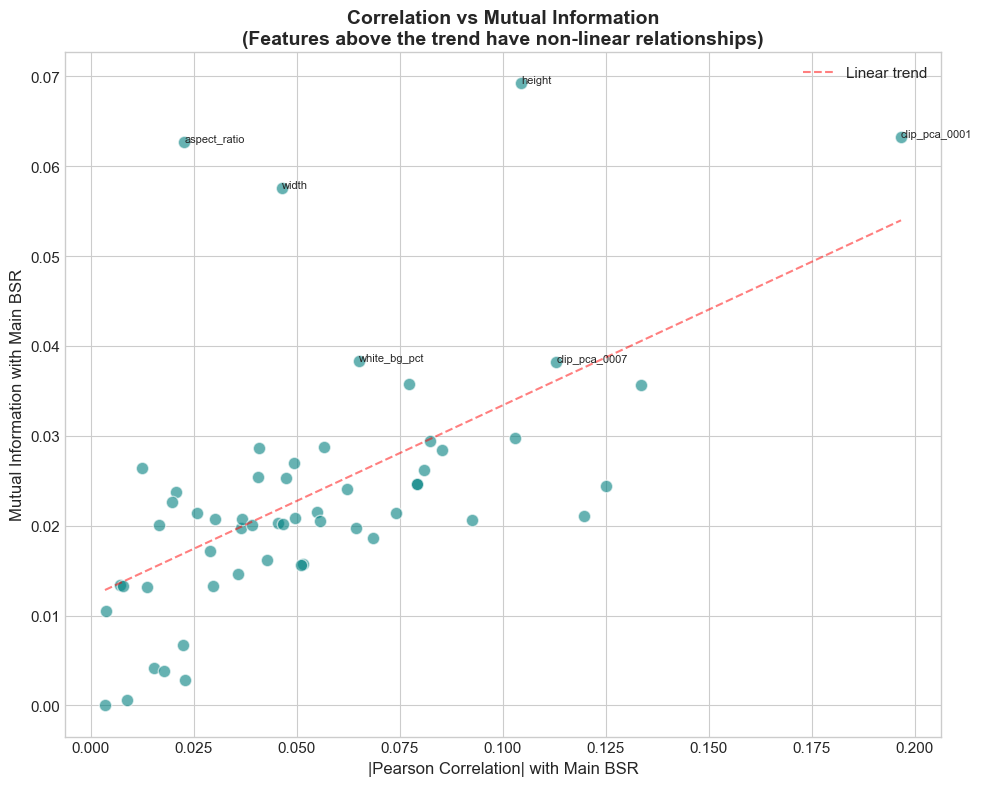

In [33]:
# Top Mutual Information Features
mi_comparison = pd.DataFrame({
    'MI_Main_BSR': mi_main,
    'MI_Lowest_BSR': mi_lowest
}).dropna()

mi_comparison['avg_MI'] = (mi_comparison['MI_Main_BSR'] + mi_comparison['MI_Lowest_BSR']) / 2
mi_comparison = mi_comparison.sort_values('avg_MI', ascending=False)

print("="*70)
print("TOP 20 FEATURES BY MUTUAL INFORMATION")
print("="*70)
print("\n(Higher MI = more predictive information about target)\n")
print(mi_comparison.head(20).round(4).to_string())

# MI vs Correlation scatter
fig, ax = plt.subplots(figsize=(10, 8))

common_idx = mi_comparison.index.intersection(comparison_df.index)
x = comparison_df.loc[common_idx, 'Main BSR (Pearson)'].abs()
y = mi_comparison.loc[common_idx, 'MI_Main_BSR']

ax.scatter(x, y, alpha=0.6, s=80, c='teal', edgecolor='white')
ax.set_xlabel('|Pearson Correlation| with Main BSR', fontsize=12)
ax.set_ylabel('Mutual Information with Main BSR', fontsize=12)
ax.set_title('Correlation vs Mutual Information\n(Features above the trend have non-linear relationships)', 
             fontweight='bold')

# Add trend line
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
ax.plot(sorted(x), p(sorted(x)), 'r--', alpha=0.5, label='Linear trend')
ax.legend()

# Annotate outliers (high MI, low correlation)
for idx in common_idx:
    if mi_comparison.loc[idx, 'MI_Main_BSR'] > y.quantile(0.9):
        ax.annotate(idx.replace('_mean', ''), (x[idx], y[idx]), fontsize=8)

plt.tight_layout()
plt.show()

---
## 10. FEATURE CORRELATION HEATMAP
Visual overview of inter-feature correlations within each feature group

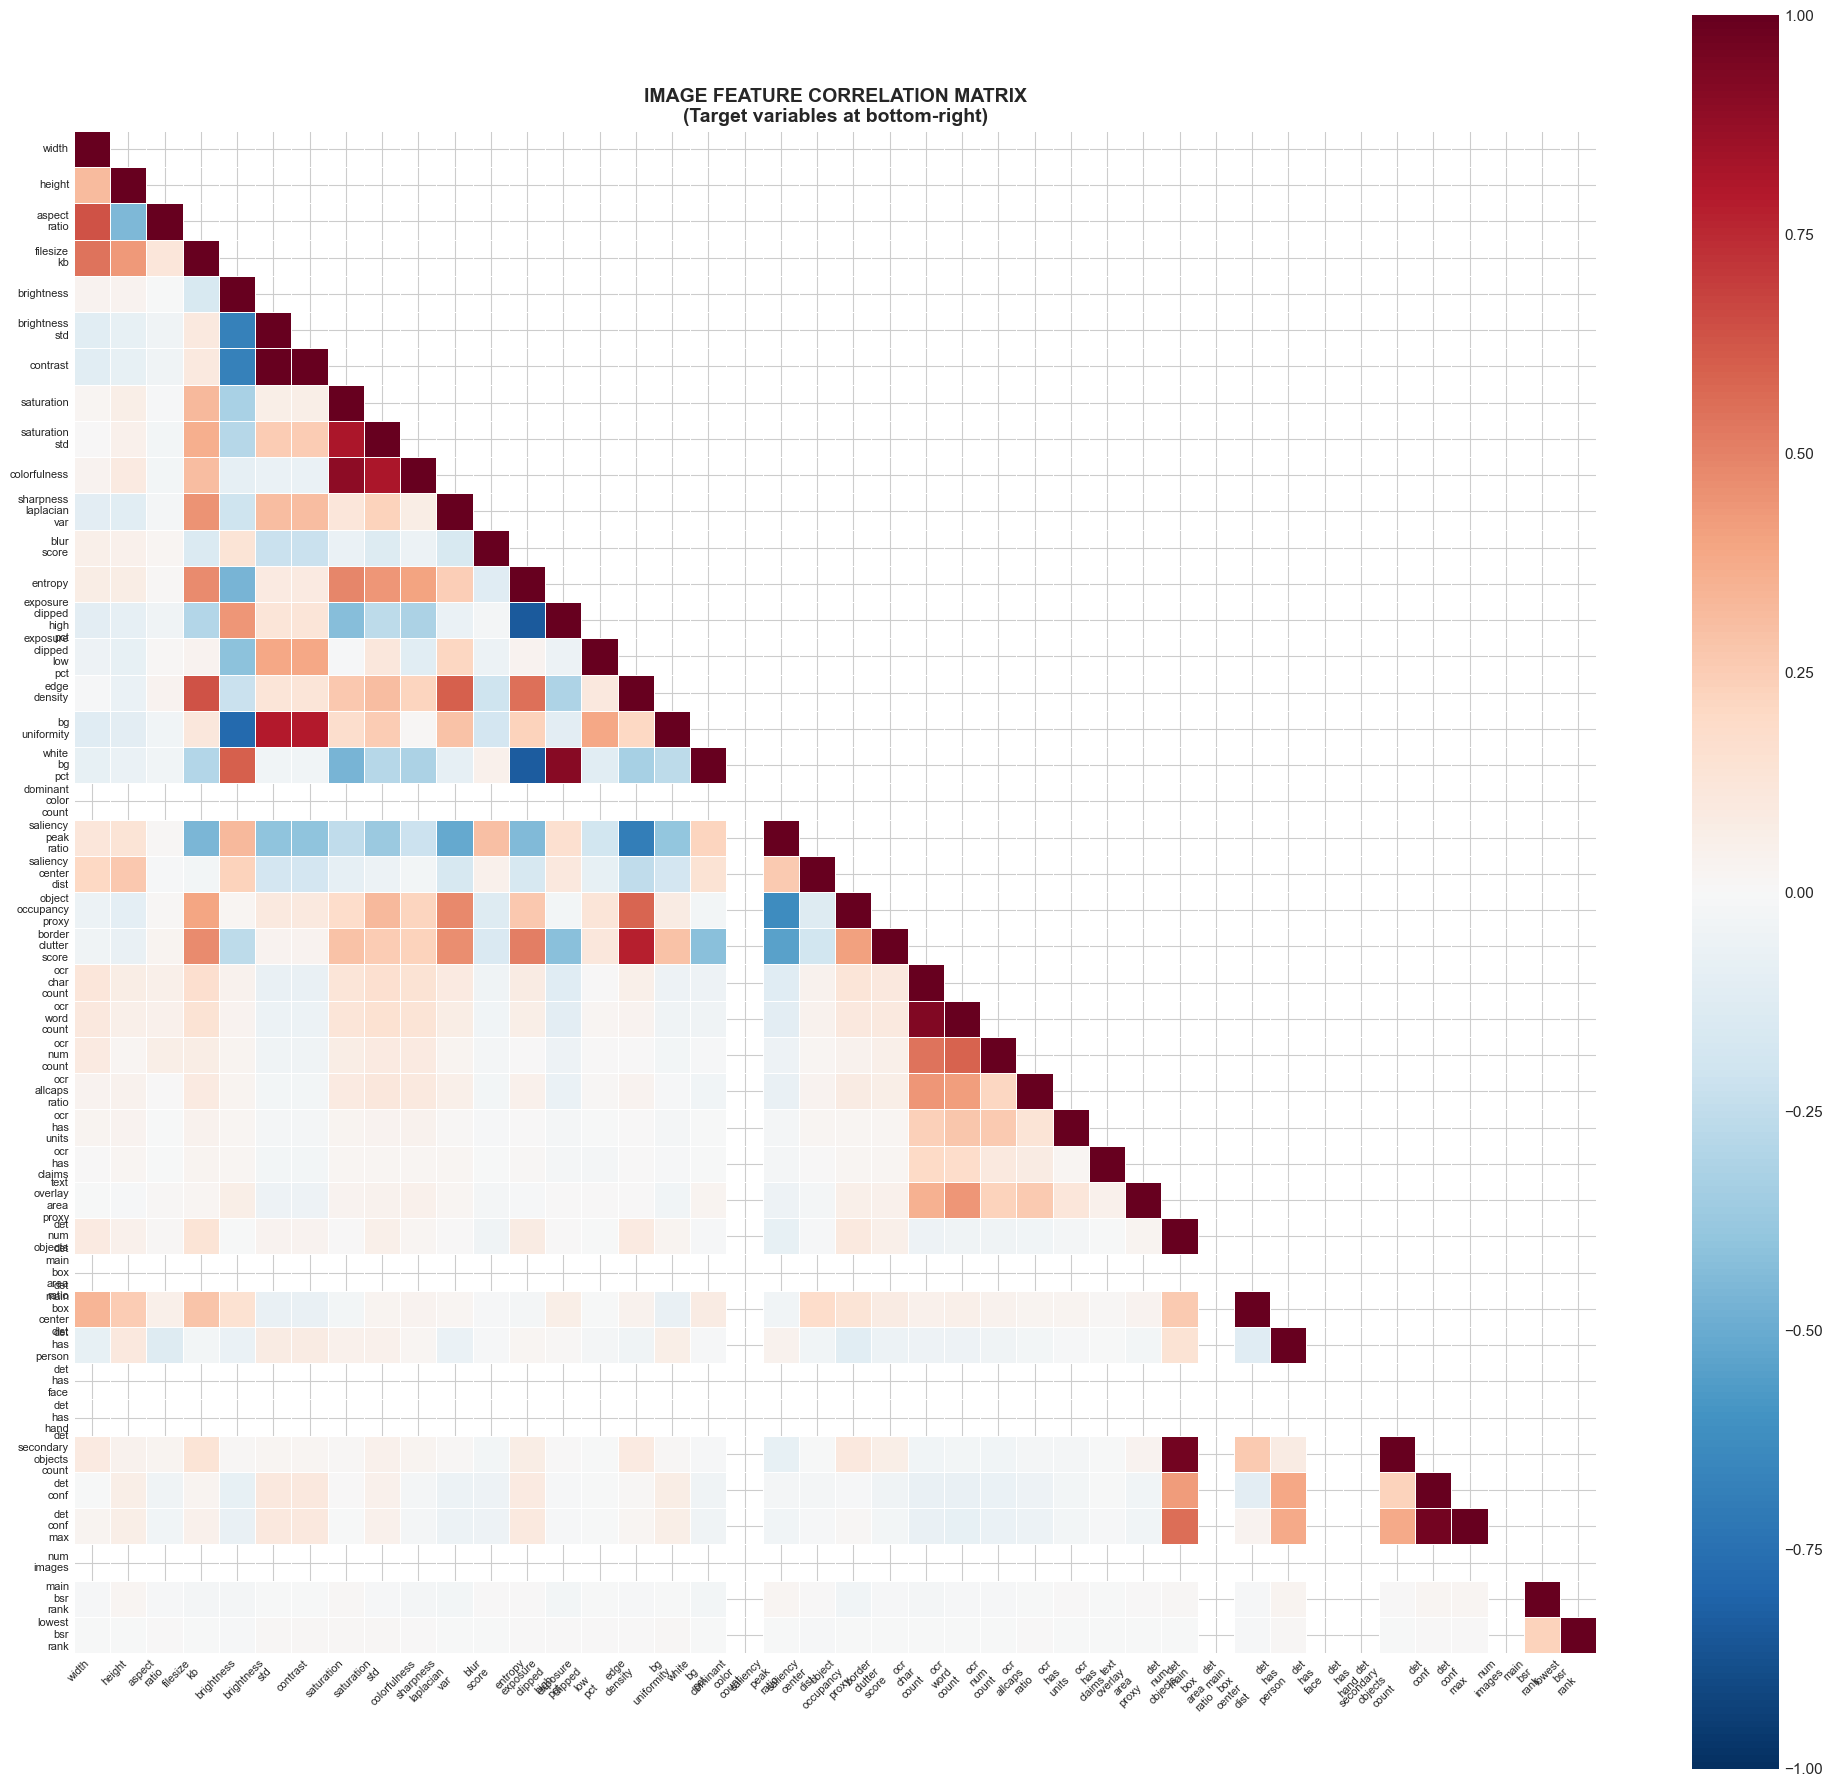

In [34]:
# Feature Correlation Heatmap (non-PCA features only)
non_pca_features = (
    get_feature_cols(QUALITY_BASE_FEATURES, '_mean') +
    get_feature_cols(COMPOSITION_BASE_FEATURES, '_mean') +
    get_feature_cols(OCR_BASE_FEATURES, '_mean') +
    get_feature_cols(DETECTION_BASE_FEATURES, '_mean') +
    ['num_images']
)
non_pca_features = [c for c in non_pca_features if c in df_analysis.columns]

# Add targets for reference
feature_for_heatmap = non_pca_features + ['main_bsr_rank', 'lowest_bsr_rank']

# Compute correlation matrix
corr_matrix = df_analysis[feature_for_heatmap].corr()

# Clean up labels
clean_labels = [s.replace('_mean', '').replace('_', '\n') for s in corr_matrix.columns]

fig, ax = plt.subplots(figsize=(20, 18))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax,
            xticklabels=clean_labels, yticklabels=clean_labels,
            vmin=-1, vmax=1)
ax.set_title('IMAGE FEATURE CORRELATION MATRIX\n(Target variables at bottom-right)', 
             fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

---
## 12. COMPREHENSIVE FEATURE RANKING
Combined ranking using multiple metrics: Pearson correlation, Spearman correlation, and Mutual Information

In [37]:
# Comprehensive Feature Ranking
# Combine all metrics

# Get common features
common_features = list(set(corr_main_pearson.index) & 
                       set(corr_lowest_pearson.index) & 
                       set(mi_main.index) & 
                       set(mi_lowest.index))

feature_ranking = pd.DataFrame(index=common_features)

# Pearson correlations (absolute)
feature_ranking['|r_main_pearson|'] = corr_main_pearson.loc[common_features, 'correlation'].abs()
feature_ranking['|r_lowest_pearson|'] = corr_lowest_pearson.loc[common_features, 'correlation'].abs()

# Spearman correlations (absolute)
feature_ranking['|r_main_spearman|'] = corr_main_spearman.loc[common_features, 'correlation'].abs()
feature_ranking['|r_lowest_spearman|'] = corr_lowest_spearman.loc[common_features, 'correlation'].abs()

# Mutual Information
feature_ranking['MI_main'] = mi_main.loc[common_features]
feature_ranking['MI_lowest'] = mi_lowest.loc[common_features]

# Normalize each metric to 0-1 range
for col in feature_ranking.columns:
    feature_ranking[f'{col}_norm'] = (feature_ranking[col] - feature_ranking[col].min()) / \
                                     (feature_ranking[col].max() - feature_ranking[col].min() + 1e-10)

# Compute composite score (average of normalized metrics)
norm_cols = [c for c in feature_ranking.columns if c.endswith('_norm')]
feature_ranking['composite_score'] = feature_ranking[norm_cols].mean(axis=1)

# Sort by composite score
feature_ranking = feature_ranking.sort_values('composite_score', ascending=False)

# Display top features
print("="*90)
print("TOP 25 IMAGE FEATURES BY COMPOSITE PREDICTIVE SCORE")
print("="*90)
print("\nMetrics: Pearson |r|, Spearman |r|, Mutual Information")
print("(Higher composite score = more predictive for BSR rank)\n")

display_cols = ['|r_main_pearson|', '|r_lowest_pearson|', 
                '|r_main_spearman|', '|r_lowest_spearman|',
                'MI_main', 'MI_lowest', 'composite_score']
print(feature_ranking[display_cols].head(25).round(4).to_string())

TOP 25 IMAGE FEATURES BY COMPOSITE PREDICTIVE SCORE

Metrics: Pearson |r|, Spearman |r|, Mutual Information
(Higher composite score = more predictive for BSR rank)

                                |r_main_pearson|  |r_lowest_pearson|  |r_main_spearman|  |r_lowest_spearman|  MI_main  MI_lowest  composite_score
clip_pca_0001                             0.1967              0.0722             0.1548               0.0754   0.0632     0.0211           0.8395
height_mean                               0.1044              0.0733             0.1449               0.0753   0.0692     0.0164           0.7451
aspect_ratio_mean                         0.0227              0.0663             0.0045               0.0664   0.0627     0.0385           0.5747
cnn_pca_0005                              0.1250              0.0315             0.1193               0.0287   0.0244     0.0207           0.4882
cnn_pca_0001                              0.1335              0.0221             0.1004               0.0

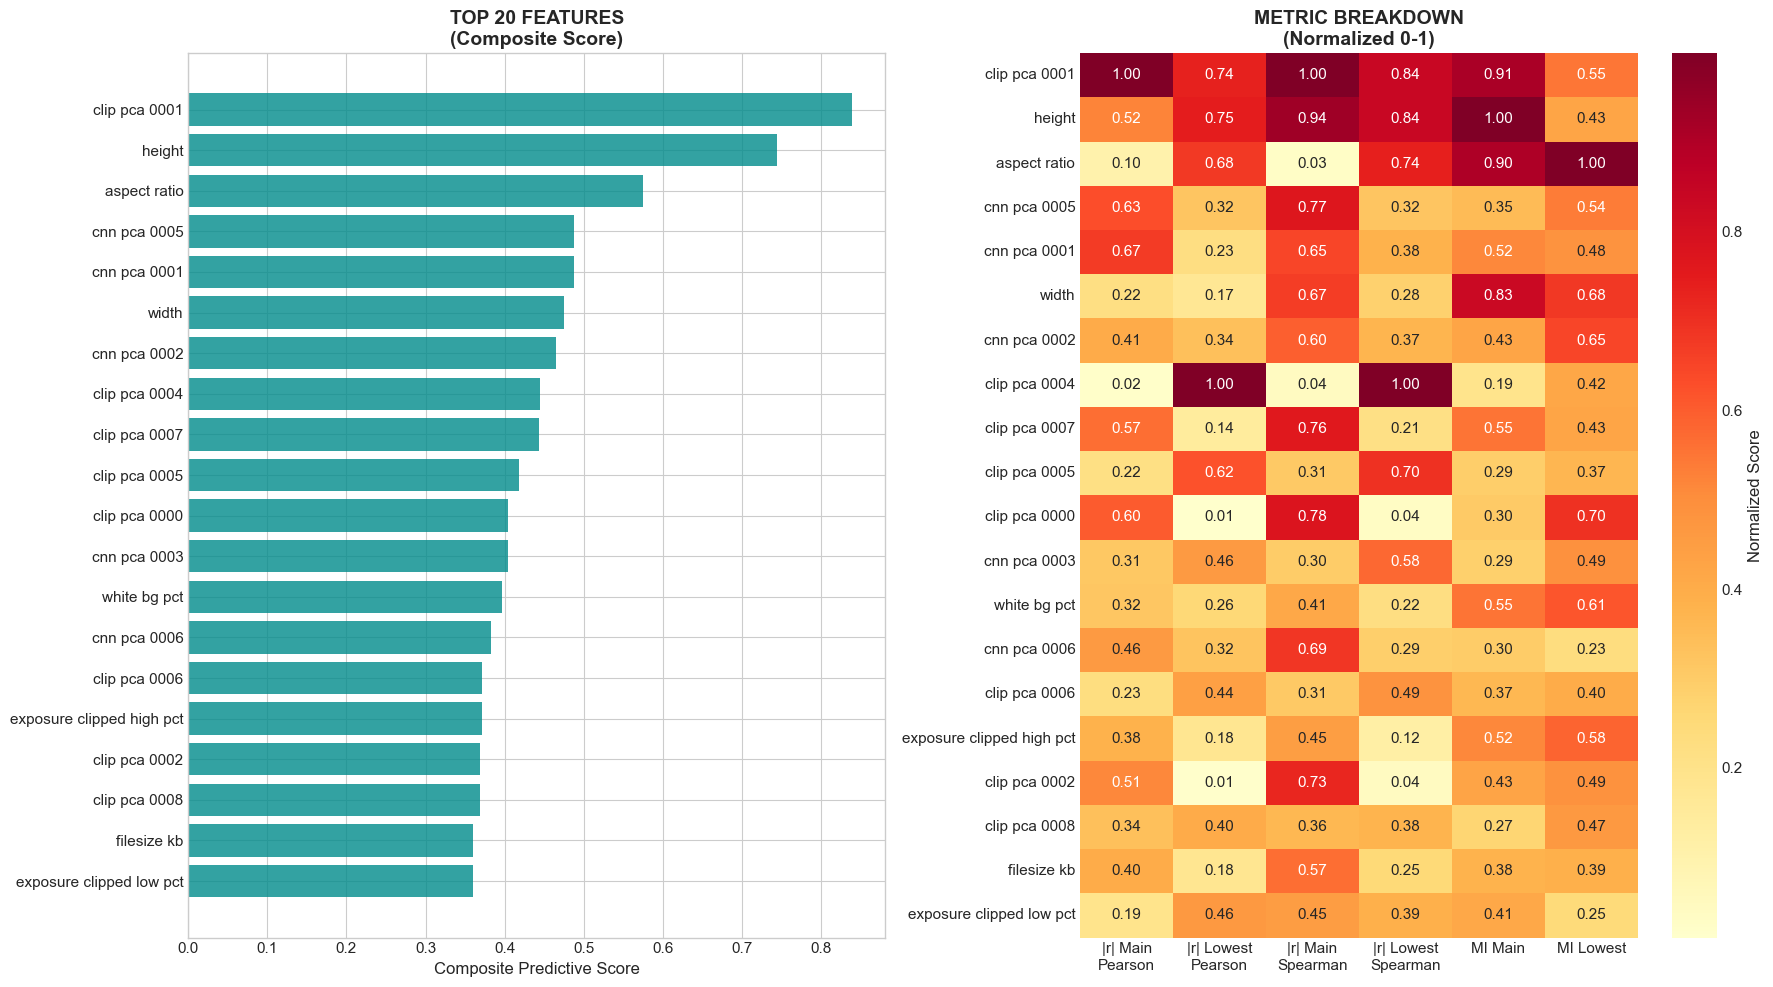

In [38]:
# Visualize Top Features by Composite Score
top_20 = feature_ranking.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Composite Score Bar Plot
ax1 = axes[0]
y_pos = range(len(top_20))
bars = ax1.barh(y_pos, top_20['composite_score'], color='darkcyan', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([s.replace('_mean', '').replace('_', ' ') for s in top_20.index])
ax1.set_xlabel('Composite Predictive Score')
ax1.set_title('TOP 20 FEATURES\n(Composite Score)', fontweight='bold')
ax1.invert_yaxis()

# Heatmap of normalized metrics for top features
ax2 = axes[1]
heatmap_data = top_20[norm_cols].copy()
heatmap_data.columns = ['|r| Main\nPearson', '|r| Lowest\nPearson', 
                        '|r| Main\nSpearman', '|r| Lowest\nSpearman',
                        'MI Main', 'MI Lowest']
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=ax2, cbar_kws={'label': 'Normalized Score'})
ax2.set_yticklabels([s.replace('_mean', '').replace('_', ' ') for s in top_20.index], rotation=0)
ax2.set_title('METRIC BREAKDOWN\n(Normalized 0-1)', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 13. SUMMARY & KEY FINDINGS

In [39]:
# Generate Summary Statistics
print("="*90)
print("IMAGE FEATURES EDA SUMMARY")
print("="*90)

print("\n📊 DATASET OVERVIEW")
print("-"*50)
print(f"Total products: {len(df):,}")
print(f"Products with image features: {len(df_with_images):,} ({len(df_with_images)/len(df)*100:.1f}%)")
print(f"Products with Main BSR target: {df_with_images['main_bsr_rank'].notna().sum():,}")
print(f"Products with Lowest BSR target: {df_with_images['lowest_bsr_rank'].notna().sum():,}")

print("\n🎯 TARGET VARIABLES")
print("-"*50)
print("TARGET 1 - Main BSR Rank:")
print(f"  Range: {main_bsr_data.min():,.0f} - {main_bsr_data.max():,.0f}")
print(f"  Median: {main_bsr_data.median():,.0f}")
print(f"  Mean: {main_bsr_data.mean():,.0f}")

print("\nTARGET 2 - Lowest BSR Rank:")
print(f"  Range: {lowest_bsr_data.min():,.0f} - {lowest_bsr_data.max():,.0f}")
print(f"  Median: {lowest_bsr_data.median():,.0f}")
print(f"  Mean: {lowest_bsr_data.mean():,.0f}")

# Target correlation
target_corr = np.corrcoef(np.log1p(both_targets['main_bsr_rank']), 
                          np.log1p(both_targets['lowest_bsr_rank']))[0, 1]
print(f"\nCorrelation between targets (log): {target_corr:.3f}")

print("\n🏆 TOP 10 MOST PREDICTIVE IMAGE FEATURES")
print("-"*50)
for i, (idx, row) in enumerate(feature_ranking.head(10).iterrows(), 1):
    clean_name = idx.replace('_mean', '').replace('_', ' ')
    print(f"{i:2}. {clean_name:35} (score: {row['composite_score']:.4f})")

print("\n📈 FEATURE GROUP ANALYSIS")
print("-"*50)

# Group the top features by type
def categorize_feature(feat_name):
    if any(q in feat_name for q in ['brightness', 'contrast', 'saturation', 'colorful', 
                                     'sharp', 'blur', 'entropy', 'exposure', 'width', 'height', 'aspect', 'filesize']):
        return 'Quality'
    elif any(c in feat_name for c in ['edge', 'bg_', 'white_bg', 'saliency', 'object_occupancy', 'border', 'dominant_color']):
        return 'Composition'
    elif 'ocr' in feat_name or 'text_overlay' in feat_name:
        return 'OCR'
    elif 'det_' in feat_name:
        return 'Detection'
    elif 'pca' in feat_name:
        return 'Embedding'
    else:
        return 'Other'

top_features_categories = [categorize_feature(f) for f in feature_ranking.head(20).index]
from collections import Counter
cat_counts = Counter(top_features_categories)
print("Feature types in Top 20:")
for cat, count in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f"  - {cat}: {count} features")

print("\n💡 KEY INSIGHTS")
print("-"*50)
print("""
1. TARGET RELATIONSHIP: Main BSR and Lowest BSR are positively correlated,
   meaning features predictive for one tend to be predictive for the other.

2. CORRELATION PATTERNS: Both Pearson and Spearman correlations reveal similar
   patterns, suggesting mostly monotonic relationships between features and targets.

3. MUTUAL INFORMATION: MI scores highlight features with non-linear predictive
   power that may be missed by linear correlation metrics.

4. FEATURE IMPORTANCE: PCA-compressed embeddings and compositional features
   tend to show strong predictive relationships with BSR ranks.

5. HERO vs AGGREGATED: Both hero image features and mean-aggregated features
   provide predictive signal - consider using both in modeling.
""")

print("="*90)
print("END OF EDA")
print("="*90)

IMAGE FEATURES EDA SUMMARY

📊 DATASET OVERVIEW
--------------------------------------------------
Total products: 36,879
Products with image features: 36,879 (100.0%)
Products with Main BSR target: 25,766
Products with Lowest BSR target: 25,766

🎯 TARGET VARIABLES
--------------------------------------------------
TARGET 1 - Main BSR Rank:
  Range: 1 - 10,101,396
  Median: 12,988
  Mean: 77,557

TARGET 2 - Lowest BSR Rank:
  Range: 1 - 5,537,959
  Median: 108
  Mean: 1,276

Correlation between targets (log): 0.645

🏆 TOP 10 MOST PREDICTIVE IMAGE FEATURES
--------------------------------------------------
 1. clip pca 0001                       (score: 0.8395)
 2. height                              (score: 0.7451)
 3. aspect ratio                        (score: 0.5747)
 4. cnn pca 0005                        (score: 0.4882)
 5. cnn pca 0001                        (score: 0.4881)
 6. width                               (score: 0.4757)
 7. cnn pca 0002                        (score: 0.46

In [40]:
# Export feature ranking for modeling reference
output_cols = ['|r_main_pearson|', '|r_lowest_pearson|', 
               '|r_main_spearman|', '|r_lowest_spearman|',
               'MI_main', 'MI_lowest', 'composite_score']
feature_ranking_export = feature_ranking[output_cols].copy()
feature_ranking_export.index.name = 'feature'
feature_ranking_export.to_csv('image_feature_ranking.csv')
print("Feature ranking exported to: image_feature_ranking.csv")
print(f"Total features ranked: {len(feature_ranking_export)}")

Feature ranking exported to: image_feature_ranking.csv
Total features ranked: 60


---
## APPENDIX: CATEGORY-LEVEL ANALYSIS
Exploring whether image feature importance varies by product category

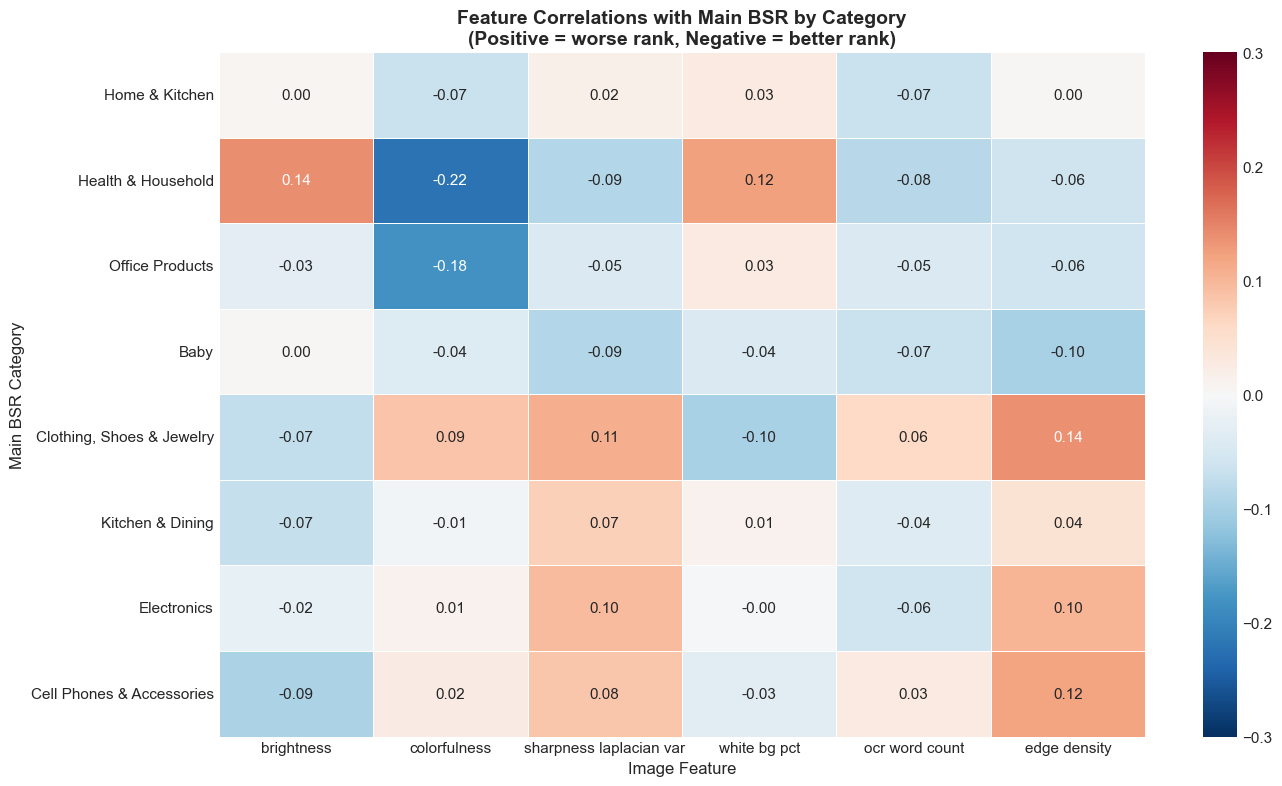


Note: Correlation patterns can vary significantly across categories.
This suggests that category-specific models may benefit from different feature subsets.


In [42]:
# Category-level feature importance analysis
# Use main_bsr_group as the category indicator

# Get top categories
top_categories = df_analysis['main_bsr_group'].value_counts().head(8).index.tolist()

# Select key features for analysis
key_features = ['brightness_mean_mean', 'colorfulness_mean', 'sharpness_laplacian_var_mean',
                'white_bg_pct_mean', 'ocr_word_count_mean', 'edge_density_mean']
key_features = [f for f in key_features if f in df_analysis.columns]

# Compute correlations by category
category_correlations = {}
for cat in top_categories:
    cat_df = df_analysis[df_analysis['main_bsr_group'] == cat]
    if len(cat_df) < 50:
        continue
    
    cat_corrs = {}
    for feat in key_features:
        mask = cat_df[feat].notna() & cat_df['main_bsr_rank'].notna()
        if mask.sum() > 20:
            corr, _ = stats.pearsonr(cat_df.loc[mask, feat], 
                                     np.log1p(cat_df.loc[mask, 'main_bsr_rank']))
            cat_corrs[feat] = corr
    category_correlations[cat] = cat_corrs

# Convert to DataFrame
cat_corr_df = pd.DataFrame(category_correlations).T
cat_corr_df.columns = [c.replace('_mean', '').replace('_', ' ') for c in cat_corr_df.columns]

# Visualize
fig, ax = plt.subplots(figsize=(14, 8))
cat_corr_df_plot = cat_corr_df.copy()
cat_corr_df_plot.index = [str(c)[:30] + '...' if len(str(c)) > 30 else str(c) for c in cat_corr_df_plot.index]
sns.heatmap(cat_corr_df_plot, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, vmin=-0.3, vmax=0.3)
ax.set_title('Feature Correlations with Main BSR by Category\n(Positive = worse rank, Negative = better rank)', 
             fontweight='bold')
ax.set_xlabel('Image Feature')
ax.set_ylabel('Main BSR Category')
plt.tight_layout()
plt.show()

print("\nNote: Correlation patterns can vary significantly across categories.")
print("This suggests that category-specific models may benefit from different feature subsets.")